# 第一阶段：项目启动与初步数据探索

本 Notebook 用于完成信贷违约预测项目的第一阶段工作。

主要目标：

- 加载本地数据集
- 识别可能的目标变量
- 检查缺失值、重复值和基础数据质量
- 为下一阶段的数据清洗和EDA做准备


## 1. 导入工具库与数据集

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

DATA_PATH = Path("credit_data.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"找不到数据文件：{DATA_PATH}")

df = pd.read_csv(DATA_PATH)
df.head()

,id,loanAmnt,term,interestRate,installment,grade,subGrade,employmentTitle,employmentLength,homeOwnership,annualIncome,verificationStatus,issueDate,isDefault,purpose,postCode,regionCode,dti,delinquency_2years,ficoRangeLow,ficoRangeHigh,openAcc,pubRec,pubRecBankruptcies,revolBal,revolUtil,totalAcc,initialListStatus,applicationType,earliesCreditLine,title,policyCode,n0,n1,n2,n3,n4,n5,n6,n7,n8,n9,n10,n11,n12,n13,n14
0,0,35000.0000,5,19.5200,917.9700,E,E2,320.0000,2 years,2,110000.0000,2,2014-07-01,1,1,137.0000,32,17.0500,0.0000,730.0000,734.0000,7.0000,0.0000,0.0000,24178.0000,48.9000,27.0000,0,0,Aug-2001,1.0000,1.0000,0.0000,2.0000,2.0000,2.0000,4.0000,9.0000,8.0000,4.0000,12.0000,2.0000,7.0000,0.0000,0.0000,0.0000,2.0000
1,1,18000.0000,5,18.4900,461.9000,D,D2,219843.0000,5 years,0,46000.0000,2,2012-08-01,0,0,156.0000,18,27.8300,0.0000,700.0000,704.0000,13.0000,0.0000,0.0000,15096.0000,38.9000,18.0000,1,0,May-2002,1723.0000,1.0000,NaN,NaN,NaN,NaN,10.0000,NaN,NaN,NaN,NaN,NaN,13.0000,NaN,NaN,NaN,NaN
2,2,12000.0000,5,16.9900,298.1700,D,D3,31698.0000,8 years,0,74000.0000,2,2015-10-01,0,0,337.0000,14,22.7700,0.0000,675.0000,679.0000,11.0000,0.0000,0.0000,4606.0000,51.8000,27.0000,0,0,May-2006,0.0000,1.0000,0.0000,0.0000,3.0000,3.0000,0.0000,0.0000,21.0000,4.0000,5.0000,3.0000,11.0000,0.0000,0.0000,0.0000,4.0000
3,3,11000.0000,3,7.2600,340.9600,A,A4,46854.0000,10+ years,1,118000.0000,1,2015-08-01,0,4,148.0000,11,17.2100,0.0000,685.0000,689.0000,9.0000,0.0000,0.0000,9948.0000,52.6000,28.0000,1,0,May-1999,4.0000,1.0000,6.0000,4.0000,6.0000,6.0000,4.0000,16.0000,4.0000,7.0000,21.0000,6.0000,9.0000,0.0000,0.0000,0.0000,1.0000
4,4,3000.0000,3,12.9900,101.0700,C,C2,54.0000,NaN,1,29000.0000,2,2016-03-01,0,10,301.0000,21,32.1600,0.0000,690.0000,694.0000,12.0000,0.0000,0.0000,2942.0000,32.0000,27.0000,0,0,Aug-1977,11.0000,1.0000,1.0000,2.0000,7.0000,7.0000,2.0000,4.0000,9.0000,10.0000,15.0000,7.0000,12.0000,0.0000,0.0000,0.0000,4.0000


## 2. 数据基础概览

### 2.1 数据形状

In [2]:
print(f"样本数量：{df.shape[0]:,}")
print(f"字段数量：{df.shape[1]:,}")

样本数量：800,000
字段数量：47


### 2.2 基础信息

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 47 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  800000 non-null  int64  
 1   loanAmnt            800000 non-null  float64
 2   term                800000 non-null  int64  
 3   interestRate        800000 non-null  float64
 4   installment         800000 non-null  float64
 5   grade               800000 non-null  str    
 6   subGrade            800000 non-null  str    
 7   employmentTitle     799999 non-null  float64
 8   employmentLength    753201 non-null  str    
 9   homeOwnership       800000 non-null  int64  
 10  annualIncome        800000 non-null  float64
 11  verificationStatus  800000 non-null  int64  
 12  issueDate           800000 non-null  str    
 13  isDefault           800000 non-null  int64  
 14  purpose             800000 non-null  int64  
 15  postCode            799999 non-null  float64


### 2.3 基础统计

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,800000.0000,NaN,NaN,NaN,399999.5000,230940.2520,0.0000,199999.7500,399999.5000,599999.2500,799999.0000
loanAmnt,800000.0000,NaN,NaN,NaN,14416.8189,8716.0862,500.0000,8000.0000,12000.0000,20000.0000,40000.0000
term,800000.0000,NaN,NaN,NaN,3.4827,0.8558,3.0000,3.0000,3.0000,3.0000,5.0000
interestRate,800000.0000,NaN,NaN,NaN,13.2384,4.7658,5.3100,9.7500,12.7400,15.9900,30.9900
installment,800000.0000,NaN,NaN,NaN,437.9477,261.4604,15.6900,248.4500,375.1350,580.7100,1715.4200
grade,800000,7,B,233690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subGrade,800000,35,C1,50763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employmentTitle,799999.0000,NaN,NaN,NaN,72005.3517,106585.6402,0.0000,427.0000,7755.0000,117663.5000,378351.0000
employmentLength,753201,11,10+ years,262753,NaN,NaN,NaN,NaN,NaN,NaN,NaN
homeOwnership,800000.0000,NaN,NaN,NaN,0.6142,0.6757,0.0000,0.0000,1.0000,1.0000,5.0000


### 2.4 缺失值统计

In [5]:
missing_summary = pd.DataFrame({
    "缺失数量": df.isna().sum(),
    "缺失比例": df.isna().mean(),
}).sort_values("缺失数量", ascending=False)

missing_summary.head(25)

,缺失数量,缺失比例
n11,69752,0.0872
employmentLength,46799,0.0585
n8,40271,0.0503
n6,40270,0.0503
n12,40270,0.0503
n9,40270,0.0503
n13,40270,0.0503
n14,40270,0.0503
n5,40270,0.0503
n0,40270,0.0503


### 2.5 区分数值字段和类别字段

In [6]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

print(f"数值字段数量： {len(numeric_cols)}")
print(numeric_cols)

print(f"\n类别/非数值字段数量： {len(categorical_cols)}")
print(categorical_cols)

数值字段数量： 42
['id', 'loanAmnt', 'term', 'interestRate', 'installment', 'employmentTitle', 'homeOwnership', 'annualIncome', 'verificationStatus', 'isDefault', 'purpose', 'postCode', 'regionCode', 'dti', 'delinquency_2years', 'ficoRangeLow', 'ficoRangeHigh', 'openAcc', 'pubRec', 'pubRecBankruptcies', 'revolBal', 'revolUtil', 'totalAcc', 'initialListStatus', 'applicationType', 'title', 'policyCode', 'n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9', 'n10', 'n11', 'n12', 'n13', 'n14']

类别/非数值字段数量： 5
['grade', 'subGrade', 'employmentLength', 'issueDate', 'earliesCreditLine']


### 2.6 目标变量检查

根据项目任务和字段说明，确认 `isDefault` 为目标变量：0表示未违约，1表示违约。

In [7]:
TARGET = "isDefault"

if TARGET not in df.columns:
    raise ValueError(f"目标字段 '{TARGET}' 没有在数据集中找到。")

target_counts = df[TARGET].value_counts(dropna=False)
target_ratio = df[TARGET].value_counts(normalize=True, dropna=False)

target_summary = pd.DataFrame({
    "count": target_counts,
    "ratio": target_ratio
})

target_summary

,count,ratio
isDefault,,
0,640390,0.8005
1,159610,0.1995


### 2.7 重复值检查

In [8]:
duplicate_rows = df.duplicated().sum()
print(f"重复行数量： {duplicate_rows:,}")

if "id" in df.columns:
    print(f"唯一 ID 数量： {df['id'].nunique():,}")
    print(f"总行数： {len(df):,}")
    print(f"id 是否唯一： {df['id'].is_unique}")

重复行数量： 0
唯一 ID 数量： 800,000
总行数： 800,000
id 是否唯一： True


# 第二阶段：数据清洗与探索性数据分析

本阶段在第一阶段数据概览的基础上完成以下工作：

- 保留原始数据，创建清洗副本
- 处理重复值和已确认的非匿名字段缺失值
- 检测业务逻辑异常和统计极端值，并只处理有明确依据的异常记录
- 保留匿名字段 `n0`～`n14` 的原始缺失值
- 检查字符串与日期字段的一致性
- 保存清洗后的数据
- 完成目标变量、数值字段、类别字段、匿名字段及时间趋势的EDA

## 1. 数据清洗

### 1.1 创建数据副本并记录清洗前状态

后续操作只修改 `df_clean`，不覆盖原始数据 `df`。

In [9]:
df_clean = df.copy()

rows_before = len(df_clean)
missing_before = int(df_clean.isna().sum().sum())

print(f"清洗前数据形状：{df_clean.shape}")
print(f"清洗前缺失值总数：{missing_before:,}")

清洗前数据形状：(800000, 47)
清洗前缺失值总数：667,448


### 1.2 删除重复记录

In [10]:
duplicate_count = int(df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().copy()

print(f"删除的重复行数：{duplicate_count:,}")
print(f"删除后数据行数：{len(df_clean):,}")

删除的重复行数：0
删除后数据行数：800,000


### 1.3 处理缺失值

- `employmentTitle`、`postCode` 和 `title` 各有 1 条缺失记录，三条记录直接删除。
- `revolUtil`、`pubRecBankruptcies` 和 `dti` 分别有 531、405 和 239 个缺失值。三个字段共影响 1,174 条不同记录，本阶段直接删除。
- `n0`～`n14` 是经过处理的匿名行为计数特征。由于缺失原因和业务含义尚不明确，本阶段保留其原始缺失值，不进行插补。
- `employmentLength` 的缺失值作为独立类别 `Unknown` 保留；特征工程阶段再新建 `employmentLength_missing`，用于区分是否提供工作年限。

In [11]:
# 定义需要删除缺失记录的字段
drop_missing_cols = [
    "employmentTitle", "postCode", "title",
    "revolUtil", "pubRecBankruptcies", "dti",
]

# 获取数据中实际存在的匿名字段
anonymous_cols = [f"n{i}" for i in range(15) if f"n{i}" in df_clean.columns]

# 找出上述字段存在任意缺失值的记录
missing_row_mask = df_clean[drop_missing_cols].isna().any(axis=1)
deleted_missing_rows = int(missing_row_mask.sum())

# 记录删除样本后匿名字段应保留的缺失数量，用于后续验证
expected_anonymous_missing = int(
    df_clean.loc[~missing_row_mask, anonymous_cols].isna().sum().sum()
)

# 删除指定字段存在缺失值的记录
df_clean = df_clean.loc[~missing_row_mask].copy()

print(f"因指定字段缺失而删除的记录数：{deleted_missing_rows:,}")

# 记录各字段采用的缺失值处理方法
missing_treatment = []

# 将工作年限缺失值保留为独立的 Unknown 类别
employment_missing_count = int(df_clean["employmentLength"].isna().sum())
df_clean["employmentLength"] = df_clean["employmentLength"].fillna("Unknown")
if employment_missing_count:
    missing_treatment.append((
        "employmentLength",
        employment_missing_count,
        "使用 Unknown 作为独立类别填补",
    ))

# 汇总本阶段已经实施的缺失值处理
missing_treatment_summary = pd.DataFrame(
    missing_treatment,
    columns=["字段", "原缺失数量", "处理方法"],
).sort_values("原缺失数量", ascending=False)

missing_treatment_summary

因指定字段缺失而删除的记录数：1,177


,字段,原缺失数量,处理方法
0,employmentLength,46541,使用 Unknown 作为独立类别填补


### 1.4 检查清洗结果

In [12]:
remaining_missing = df_clean.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
non_anonymous_cols = [column for column in df_clean.columns if column not in anonymous_cols]
non_anonymous_missing_count = int(df_clean[non_anonymous_cols].isna().sum().sum())
anonymous_missing_count = int(df_clean[anonymous_cols].isna().sum().sum())
numeric_array = df_clean.select_dtypes(include="number").to_numpy()
infinite_count = int(np.isinf(numeric_array).sum())

cleaning_summary = pd.DataFrame({
    "检查项": [
        "清洗前行数", "清洗后行数", "删除重复行数",
        "删除指定缺失字段行数", "清洗前缺失值总数", "保留的匿名字段缺失值数量",
        "其他字段待处理缺失值数量", "数值字段无穷值数量",
    ],
    "结果": [
        rows_before, len(df_clean), duplicate_count,
        deleted_missing_rows, missing_before, anonymous_missing_count,
        non_anonymous_missing_count, infinite_count,
    ],
})

display(cleaning_summary)
if not remaining_missing.empty:
    display(remaining_missing.to_frame("保留的缺失数量"))

assert df_clean.duplicated().sum() == 0, "清洗后仍存在重复行"
assert df_clean[TARGET].isna().sum() == 0, "目标字段存在缺失值"
assert infinite_count == 0, "数值字段中仍存在无穷值"
assert anonymous_missing_count == expected_anonymous_missing, "匿名字段缺失值被意外修改"

,检查项,结果
0,清洗前行数,800000
1,清洗后行数,798823
2,删除重复行数,0
3,删除指定缺失字段行数,1177
4,清洗前缺失值总数,667448
5,保留的匿名字段缺失值数量,612519
6,其他字段待处理缺失值数量,0
7,数值字段无穷值数量,0


,保留的缺失数量
n11,69288
n8,39807
n0,39806
n3,39806
n5,39806
n1,39806
n2,39806
n13,39806
n6,39806
n9,39806


## 2. 异常值检测与处理

异常值检测分为两类：

- **业务逻辑异常**：违反字段已知定义或字段间逻辑关系的取值，可以在有明确依据时处理。
- **统计极端值**：位于 IQR 边界之外的长尾取值，只表示少见，不等于错误数据。

本阶段不使用统一的统计阈值批量删除样本，避免误删真实的高风险借款人。匿名字段 `n0`～`n14` 仅检查非缺失值是否为非负整数；由于具体业务含义未知，不使用IQR判断或删除其统计极端值。

### 2.1 全部数值字段的业务逻辑异常检测

本部分按照字段定义检查全部数值字段：应该大于0的字段检查正数，允许为0的字段检查非负数，计数或编码字段同时检查是否为整数，特殊字段使用各自规则。代码通过字段覆盖断言保证没有遗漏任何数值字段。

字符串字段和日期字段不适用数值规则，将在2.6中单独检查。对于没有提供编码映射的字段，只检查非负整数，不自行规定合法编码集合。

In [13]:
# 将全部数值字段按业务规则分组
positive_cols = [
    "loanAmnt", "interestRate", "installment",
]
positive_integer_cols = [
    "term", "ficoRangeLow", "ficoRangeHigh",
]
non_negative_cols = [
    "annualIncome", "dti", "revolBal", "revolUtil",
]
non_negative_integer_cols = [
    "employmentTitle", "homeOwnership", "verificationStatus", "purpose",
    "regionCode", "delinquency_2years", "openAcc", "pubRec",
    "pubRecBankruptcies", "totalAcc", "initialListStatus",
    "applicationType", "title",
]
anonymous_integer_cols = [
    f"n{i}" for i in range(15) if f"n{i}" in df_clean.columns
]
special_rule_cols = ["id", TARGET, "postCode", "policyCode"]

# 检查分组是否覆盖全部数值字段，防止新增字段或漏检
numeric_cols_in_data = set(df_clean.select_dtypes(include="number").columns)
covered_numeric_cols = set(
    positive_cols
    + positive_integer_cols
    + non_negative_cols
    + non_negative_integer_cols
    + anonymous_integer_cols
    + special_rule_cols
)

uncovered_numeric_cols = sorted(numeric_cols_in_data - covered_numeric_cols)
unknown_grouped_cols = sorted(covered_numeric_cols - numeric_cols_in_data)

assert not uncovered_numeric_cols, f"存在未检查的数值字段：{uncovered_numeric_cols}"
assert not unknown_grouped_cols, f"检查列表中存在数据里没有的字段：{unknown_grouped_cols}"


def invalid_non_integer(series):
    """返回非缺失值中带有小数部分的位置。"""
    return series.notna() & (series % 1 != 0)


def build_business_logic_summary(data):
    """逐字段统计业务逻辑异常，确保结果能够定位到具体字段。"""
    checks = []

    for column in positive_cols:
        checks.append((
            column,
            "必须大于0",
            int((data[column] <= 0).sum()),
        ))

    for column in positive_integer_cols:
        invalid = (data[column] <= 0) | invalid_non_integer(data[column])
        checks.append((
            column,
            "必须为正整数",
            int(invalid.sum()),
        ))

    for column in non_negative_cols:
        checks.append((
            column,
            "必须大于或等于0",
            int((data[column] < 0).sum()),
        ))

    for column in non_negative_integer_cols:
        invalid = (data[column] < 0) | invalid_non_integer(data[column])
        checks.append((
            column,
            "必须为非负整数",
            int(invalid.sum()),
        ))

    for column in anonymous_integer_cols:
        invalid = (data[column] < 0) | invalid_non_integer(data[column])
        checks.append((
            column,
            "非缺失值必须为非负整数",
            int(invalid.sum()),
        ))

    id_invalid = (data["id"] < 0) | invalid_non_integer(data["id"])
    checks.append((
        "id",
        "必须为非负整数且唯一",
        int(id_invalid.sum() + data["id"].duplicated().sum()),
    ))
    checks.append((
        TARGET,
        "只能取0或1",
        int((~data[TARGET].isin([0, 1])).sum()),
    ))

    post_code_invalid = (
        (data["postCode"] < 0)
        | (data["postCode"] > 999)
        | invalid_non_integer(data["postCode"])
    )
    checks.append((
        "postCode",
        "必须为0至999之间的整数",
        int(post_code_invalid.sum()),
    ))
    checks.append((
        "policyCode",
        "只能取1或2",
        int((~data["policyCode"].isin([1, 2])).sum()),
    ))

    checks.extend([
        (
            "ficoRangeLow / ficoRangeHigh",
            "下限不能大于上限",
            int((data["ficoRangeLow"] > data["ficoRangeHigh"]).sum()),
        ),
        (
            "ficoRangeLow / ficoRangeHigh",
            "常用300至850范围（参考性检查）",
            int(((data["ficoRangeLow"] < 300) | (data["ficoRangeHigh"] > 850)).sum()),
        ),
        (
            "openAcc / totalAcc",
            "未结信用额度数量不能大于总信用额度数量",
            int((data["openAcc"] > data["totalAcc"]).sum()),
        ),
    ])

    return pd.DataFrame(
        checks,
        columns=["字段", "检查规则", "异常数量"],
    )


# 展示各类规则覆盖的字段，便于人工复核
numeric_rule_summary = pd.DataFrame({
    "规则": [
        "必须大于0", "必须为正整数", "必须为非负数",
        "必须为非负整数", "匿名非负整数", "特殊规则",
    ],
    "字段": [
        positive_cols, positive_integer_cols, non_negative_cols,
        non_negative_integer_cols, anonymous_integer_cols, special_rule_cols,
    ],
})
display(numeric_rule_summary)

business_logic_summary = build_business_logic_summary(df_clean)
display(business_logic_summary)

,规则,字段
0,必须大于0,"[loanAmnt, interestRate, installment]"
1,必须为正整数,"[term, ficoRangeLow, ficoRangeHigh]"
2,必须为非负数,"[annualIncome, dti, revolBal, revolUtil]"
3,必须为非负整数,"[employmentTitle, homeOwnership, verificationS..."
4,匿名非负整数,"[n0, n1, n2, n3, n4, n5, n6, n7, n8, n9, n10, ..."
5,特殊规则,"[id, isDefault, postCode, policyCode]"


,字段,检查规则,异常数量
0,loanAmnt,必须大于0,0
1,interestRate,必须大于0,0
2,installment,必须大于0,0
3,term,必须为正整数,0
4,ficoRangeLow,必须为正整数,0
5,ficoRangeHigh,必须为正整数,0
6,annualIncome,必须大于或等于0,0
7,dti,必须大于或等于0,2
8,revolBal,必须大于或等于0,0
9,revolUtil,必须大于或等于0,0


### 2.2 处理明确异常值

根据已确认的字段定义，`dti` 表示债务收入比，正常情况下不应为负数。数据中有 2 条记录的 `dti=-1`，将其视为无效值或特殊编码。由于前一步已经选择删除 `dti` 缺失记录，本阶段也直接删除这 2 条记录，以保持规则一致。

In [14]:
# 删除债务收入比为负数的记录
negative_dti_mask = df_clean["dti"] < 0
deleted_negative_dti_rows = int(negative_dti_mask.sum())
df_clean = df_clean.loc[~negative_dti_mask].copy()

print(f"删除的负数 dti 记录数：{deleted_negative_dti_rows:,}")
print(f"异常值处理后数据行数：{len(df_clean):,}")

删除的负数 dti 记录数：2
异常值处理后数据行数：798,821


### 2.3 统计极端值检测

以下使用 IQR 方法统计数值字段的极端值数量，并展示Q1、Q3、最小值、中位数和最大值。Q1和Q3用于计算IQR边界。

`delinquency_2years`、`pubRec` 和 `pubRecBankruptcies` 保留在汇总表中用于观察分布，但它们的0值占比均超过75%，导致Q1和Q3都等于0，IQR方法会把所有非零值标记为极端值，因此这三个字段的IQR结果不参与清洗或删除。

类别编码、ID、目标变量和匿名字段不参与该统计。

In [15]:
outlier_check_cols = [
    "loanAmnt", "interestRate", "installment", "annualIncome", "dti",
    "delinquency_2years", "ficoRangeLow", "ficoRangeHigh", "openAcc",
    "pubRec", "pubRecBankruptcies", "revolBal", "revolUtil", "totalAcc",
]

outlier_rows = []
for column in outlier_check_cols:
    series = df_clean[column].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = int(((series < lower_bound) | (series > upper_bound)).sum())

    outlier_rows.append({
        "字段": column,
        "最小值": series.min(),
        "Q1": q1,
        "中位数": series.median(),
        "Q3": q3,
        "最大值": series.max(),
        "IQR下界": lower_bound,
        "IQR上界": upper_bound,
        "IQR极端值数量": outlier_count,
        "IQR极端值比例": outlier_count / len(series),
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values(
    "IQR极端值比例", ascending=False
)
display(outlier_summary.style.hide(axis="index"))

字段,最小值,Q1,中位数,Q3,最大值,IQR下界,IQR上界,IQR极端值数量,IQR极端值比例
delinquency_2years,0.000000,0.000000,0.000000,0.000000,39.000000,0.000000,0.000000,154067,0.192868
pubRec,0.000000,0.000000,0.000000,0.000000,86.000000,0.000000,0.000000,135169,0.169211
pubRecBankruptcies,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,99484,0.124539
revolBal,0.000000,5953.000000,11139.000000,19740.000000,2904836.000000,-14727.500000,40420.500000,47271,0.059176
annualIncome,20.000000,45614.000000,65000.000000,90000.000000,10999200.000000,-20965.000000,156579.000000,38939,0.048746
ficoRangeLow,660.000000,670.000000,690.000000,710.000000,845.000000,610.000000,770.000000,27576,0.034521
ficoRangeHigh,664.000000,674.000000,694.000000,714.000000,850.000000,614.000000,774.000000,27576,0.034521
openAcc,1.000000,8.000000,11.000000,14.000000,86.000000,-1.000000,23.000000,27422,0.034328
installment,19.870000,248.480000,375.190000,580.730000,1715.420000,-249.895000,1079.105000,24949,0.031232
interestRate,5.310000,9.750000,12.740000,15.990000,30.990000,0.390000,25.350000,14772,0.018492


### 2.4 IQR极端值处理

本阶段只根据IQR边界删除 `revolUtil` 的极端值记录。`delinquency_2years`、`pubRec`、`pubRecBankruptcies` 因0值高度集中不参与IQR删除；`dti` 的IQR极端值也予以保留。其他字段的统计极端值可能具有实际风险识别意义，同样不删除。

这里的处理用于生成当前清洗数据。正式划分训练集和测试集后，IQR边界应只根据训练集重新计算，再将相同边界应用到测试集。

In [16]:
# 从前面的IQR汇总结果中读取revolUtil边界
revolutil_iqr_row = outlier_summary.loc[
    outlier_summary["字段"] == "revolUtil"
].iloc[0]
revolutil_lower_bound = revolutil_iqr_row["IQR下界"]
revolutil_upper_bound = revolutil_iqr_row["IQR上界"]

# 只删除revolUtil超出IQR范围的记录
revolutil_outlier_mask = (
    (df_clean["revolUtil"] < revolutil_lower_bound)
    | (df_clean["revolUtil"] > revolutil_upper_bound)
)
deleted_revolutil_outliers = int(revolutil_outlier_mask.sum())
df_clean = df_clean.loc[~revolutil_outlier_mask].copy()

revolutil_treatment_summary = pd.DataFrame({
    "字段": ["revolUtil"],
    "IQR下界": [revolutil_lower_bound],
    "IQR上界": [revolutil_upper_bound],
    "删除记录数": [deleted_revolutil_outliers],
    "处理后最大值": [df_clean["revolUtil"].max()],
})
display(revolutil_treatment_summary.style.hide(axis="index"))

assert not (
    (df_clean["revolUtil"] < revolutil_lower_bound)
    | (df_clean["revolUtil"] > revolutil_upper_bound)
).any(), "处理后仍存在超出IQR范围的revolUtil记录"

字段,IQR下界,IQR上界,删除记录数,处理后最大值
revolUtil,-22.300000,126.500000,47,126.400000


### 2.5 异常值处理结果检查

处理后对全部数值字段重新运行相同的业务逻辑检查，并确认 `revolUtil` 已不存在超出原IQR边界的记录。`delinquency_2years`、`pubRec`、`pubRecBankruptcies`、`dti` 以及其他字段的统计极端值均保留，不参与本次IQR清洗。字符串和日期字段在2.6中进行一致性检查。

In [17]:
# 使用与处理前相同的函数重新检查
post_outlier_checks = build_business_logic_summary(df_clean)
display(post_outlier_checks)

assert deleted_negative_dti_rows == 2, "负数 dti 记录数量与检测结果不一致"
assert post_outlier_checks["异常数量"].sum() == 0, "处理后仍存在已确认的业务逻辑异常"

,字段,检查规则,异常数量
0,loanAmnt,必须大于0,0
1,interestRate,必须大于0,0
2,installment,必须大于0,0
3,term,必须为正整数,0
4,ficoRangeLow,必须为正整数,0
5,ficoRangeHigh,必须为正整数,0
6,annualIncome,必须大于或等于0,0
7,dti,必须大于或等于0,0
8,revolBal,必须大于或等于0,0
9,revolUtil,必须大于或等于0,0


### 2.6 字符串与日期字段一致性检查

本部分不转换或覆盖原始字符串，只检查空字符串、首尾空格、等级对应关系、工作年限类别以及日期能否按预期格式解析。日期转换仍留到特征工程阶段。

In [18]:
string_cols = [
    "grade", "subGrade", "employmentLength", "issueDate", "earliesCreditLine",
]

# 检查字符串中的空值和首尾空格。
consistency_checks = []
for column in string_cols:
    string_values = df_clean[column].astype("string")
    consistency_checks.extend([
        (column, "空字符串", int(string_values.fillna("").str.strip().eq("").sum())),
        (
            column,
            "存在首尾空格",
            int((string_values.notna() & string_values.ne(string_values.str.strip())).sum()),
        ),
    ])

# 检查等级、工作年限和日期字段内部的一致性。
valid_employment_lengths = {
    "< 1 year", "1 year", "2 years", "3 years", "4 years", "5 years",
    "6 years", "7 years", "8 years", "9 years", "10+ years", "Unknown",
}
issue_date_check = pd.to_datetime(
    df_clean["issueDate"], format="%Y-%m-%d", errors="coerce"
)
earliest_credit_check = pd.to_datetime(
    df_clean["earliesCreditLine"], format="%b-%Y", errors="coerce"
)

consistency_checks.extend([
    (
        "grade / subGrade",
        "subGrade首字母与grade不一致",
        int(df_clean["subGrade"].str[0].ne(df_clean["grade"]).sum()),
    ),
    (
        "employmentLength",
        "不在预期类别中",
        int((~df_clean["employmentLength"].isin(valid_employment_lengths)).sum()),
    ),
    ("issueDate", "无法按YYYY-MM-DD解析", int(issue_date_check.isna().sum())),
    ("issueDate", "日期不是每月1日", int(issue_date_check.dt.day.ne(1).sum())),
    (
        "earliesCreditLine",
        "无法按Mon-YYYY解析",
        int(earliest_credit_check.isna().sum()),
    ),
    (
        "日期关系",
        "最早信用额度开立月份晚于贷款发放月份",
        int((earliest_credit_check > issue_date_check).sum()),
    ),
])

consistency_summary = pd.DataFrame(
    consistency_checks,
    columns=["字段", "检查规则", "异常数量"],
)
display(consistency_summary.style.hide(axis="index"))

assert consistency_summary["异常数量"].sum() == 0, "字符串或日期字段存在一致性异常"

字段,检查规则,异常数量
grade,空字符串,0
grade,存在首尾空格,0
subGrade,空字符串,0
subGrade,存在首尾空格,0
employmentLength,空字符串,0
employmentLength,存在首尾空格,0
issueDate,空字符串,0
issueDate,存在首尾空格,0
earliesCreditLine,空字符串,0
earliesCreditLine,存在首尾空格,0


## 3. 保存清洗后的数据

In [19]:
CLEAN_DATA_PATH = Path("credit_data_cleaned.csv")
df_clean.to_csv(CLEAN_DATA_PATH, index=False)

file_size_mb = CLEAN_DATA_PATH.stat().st_size / (1024 ** 2)
print(f"清洗后数据已保存至：{CLEAN_DATA_PATH}")
print(f"文件大小：{file_size_mb:.2f} MB")
print(f"保存的数据形状：{df_clean.shape}")

清洗后数据已保存至：credit_data_cleaned.csv
文件大小：167.61 MB
保存的数据形状：(798774, 47)


## 4. 探索性数据分析（EDA）

### 4.1 目标变量分布

,样本数量,样本占比
isDefault,,
0,639420,0.8005
1,159354,0.1995


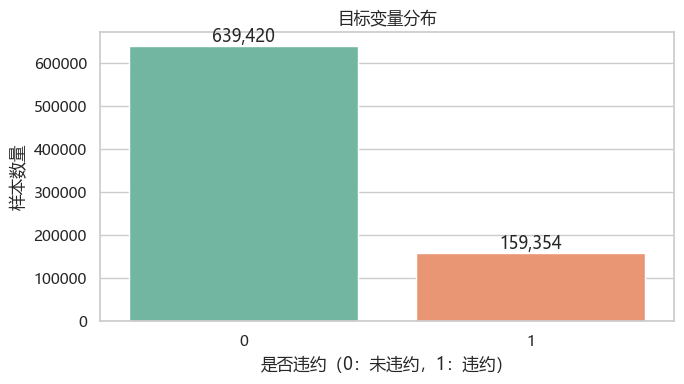

In [20]:
target_eda = df_clean[TARGET].value_counts().sort_index().to_frame("样本数量")
target_eda["样本占比"] = target_eda["样本数量"] / len(df_clean)
display(target_eda)

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df_clean, x=TARGET, hue=TARGET, palette="Set2", legend=False, ax=ax)
ax.set_title("目标变量分布")
ax.set_xlabel("是否违约（0：未违约，1：违约）")
ax.set_ylabel("样本数量")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")
plt.tight_layout()
plt.show()

目标变量分布用于判断类别是否平衡。若类别比例差异明显，建模阶段应结合分层抽样、类别权重以及 AUC、F1、召回率等指标进行评价。

### 4.2 主要数值字段分布

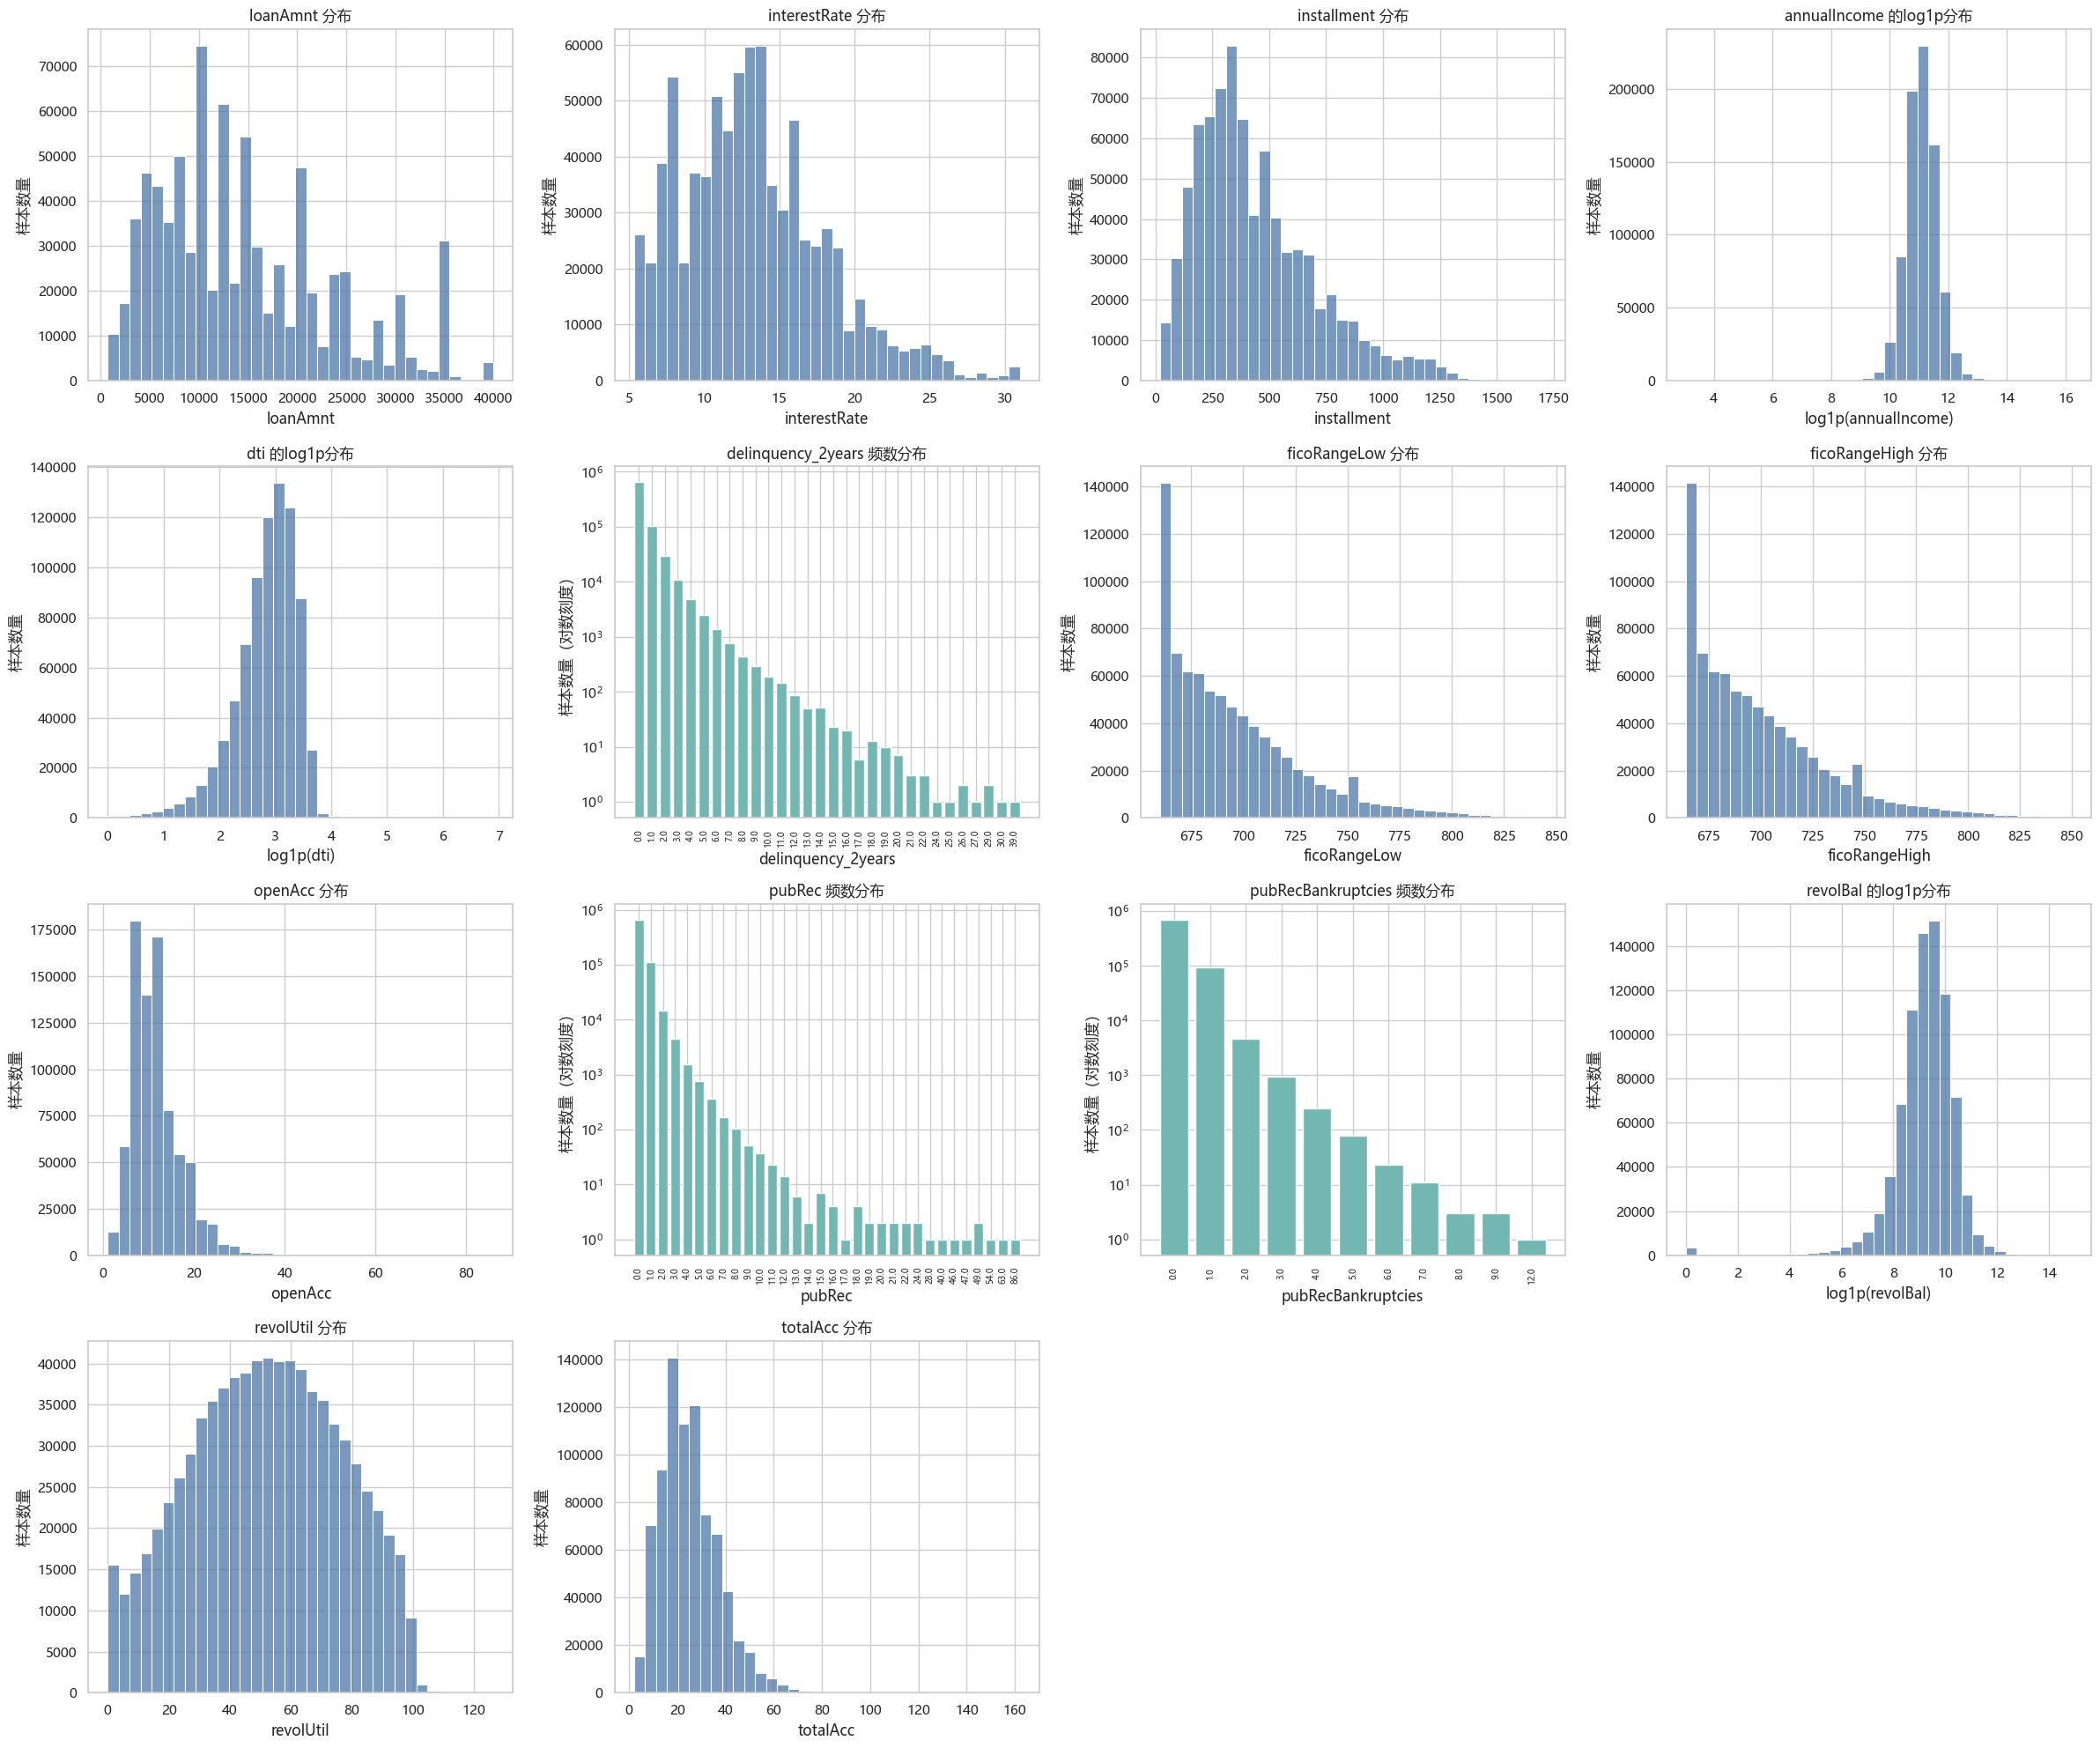

In [21]:
# 选择具有明确数值含义、适合观察连续或计数分布的字段。
eda_numeric_cols = [
    "loanAmnt", "interestRate", "installment", "annualIncome", "dti",
    "delinquency_2years", "ficoRangeLow", "ficoRangeHigh", "openAcc",
    "pubRec", "pubRecBankruptcies", "revolBal", "revolUtil", "totalAcc",
]

# 使用全部样本，转换仅用于绘图，不修改df_clean。
plot_data = df_clean
# 右偏连续字段仅在绘图时使用log1p，三个零值集中的计数字段使用对数频数轴。
log_hist_cols = {"annualIncome", "dti", "revolBal"}
count_bar_cols = {"delinquency_2years", "pubRec", "pubRecBankruptcies"}

fig, axes = plt.subplots(4, 4, figsize=(24, 20))
for column, ax in zip(eda_numeric_cols, axes.flat):
    if column in log_hist_cols:
        sns.histplot(
            np.log1p(plot_data[column]),
            bins=35,
            kde=False,
            ax=ax,
            color="#4C78A8",
        )
        ax.set_title(f"{column} 的log1p分布")
        ax.set_xlabel(f"log1p({column})")
        ax.set_ylabel("样本数量")
    elif column in count_bar_cols:
        frequency = plot_data[column].value_counts().sort_index()
        ax.bar(
            frequency.index.astype(str),
            frequency.values,
            color="#72B7B2",
        )
        ax.set_yscale("log")
        ax.set_title(f"{column} 频数分布")
        ax.set_xlabel(column)
        ax.set_ylabel("样本数量（对数刻度）")
        ax.tick_params(axis="x", rotation=90, labelsize=7)
    else:
        sns.histplot(
            plot_data[column],
            bins=35,
            kde=False,
            ax=ax,
            color="#4C78A8",
        )
        ax.set_title(f"{column} 分布")
        ax.set_xlabel(column)
        ax.set_ylabel("样本数量")

for ax in axes.flat[len(eda_numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

图形使用全部清洗样本。`annualIncome`、`dti`、`revolBal` 只在绘图时使用 `log1p` 压缩右侧长尾；`delinquency_2years`、`pubRec`、`pubRecBankruptcies` 保留原始计数，使用频数柱状图和对数纵轴显示低频高值。其他字段使用原始直方图。上述绘图转换不会修改清洗数据。

### 4.3 类别与离散字段的单变量分布

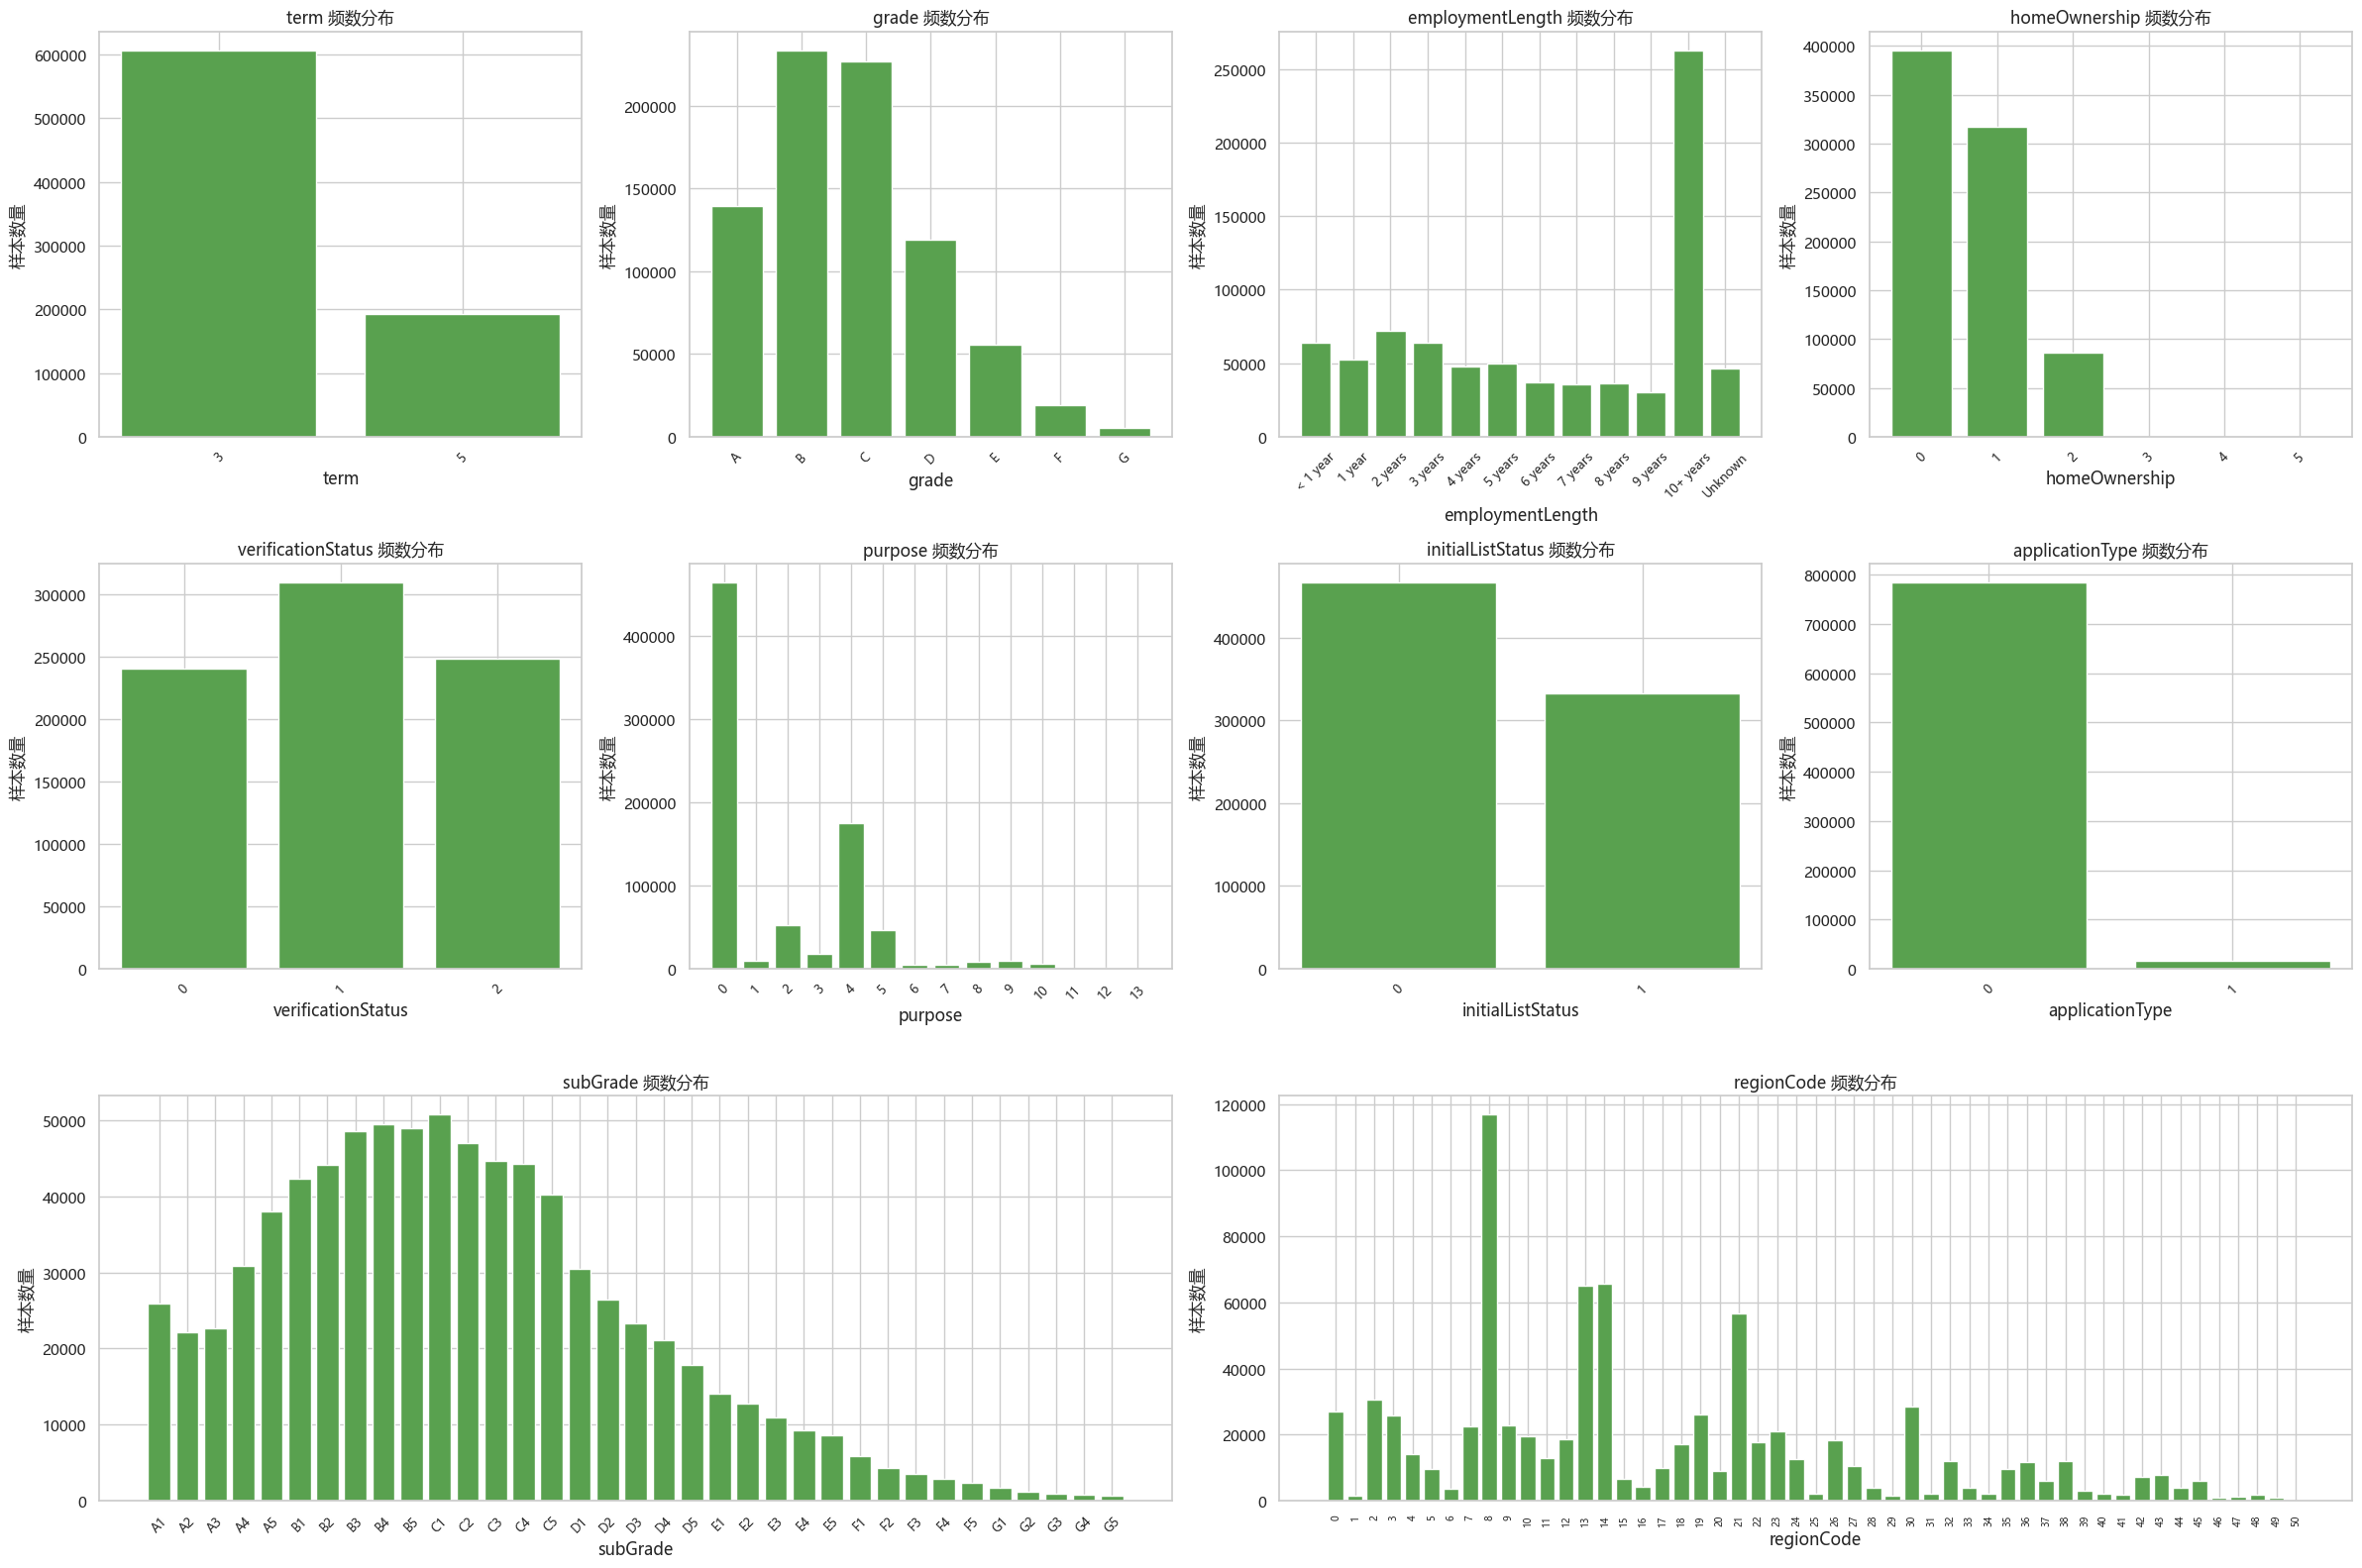

In [22]:
# 类别字段使用频数柱状图，不把数值编码解释为连续数值。
eda_categorical_distribution_cols = [
    "term", "grade", "subGrade", "employmentLength",
    "homeOwnership", "verificationStatus", "purpose", "regionCode",
    "initialListStatus", "applicationType",
]

employment_length_order = [
    "< 1 year", "1 year", "2 years", "3 years", "4 years",
    "5 years", "6 years", "7 years", "8 years", "9 years",
    "10+ years", "Unknown",
]

# 类别较多的subGrade和regionCode在最后一行使用加宽子图。
regular_categorical_cols = [
    column
    for column in eda_categorical_distribution_cols
    if column not in {"subGrade", "regionCode"}
]

fig = plt.figure(figsize=(24, 16))
grid = fig.add_gridspec(3, 4)
axes_by_column = {
    column: fig.add_subplot(grid[index // 4, index % 4])
    for index, column in enumerate(regular_categorical_cols)
}
axes_by_column["subGrade"] = fig.add_subplot(grid[2, :2])
axes_by_column["regionCode"] = fig.add_subplot(grid[2, 2:])

for column in eda_categorical_distribution_cols:
    ax = axes_by_column[column]
    frequency = plot_data[column].value_counts(dropna=False)

    if column == "employmentLength":
        category_order = [value for value in employment_length_order if value in frequency.index]
        frequency = frequency.reindex(category_order)
    else:
        frequency = frequency.sort_index()

    ax.bar(
        frequency.index.astype(str),
        frequency.values,
        color="#59A14F",
    )
    ax.set_title(f"{column} 频数分布")
    ax.set_xlabel(column)
    ax.set_ylabel("样本数量")
    ax.tick_params(
        axis="x",
        rotation=90 if column == "regionCode" else 45,
        labelsize=7 if column == "regionCode" else 9,
    )

plt.tight_layout()
plt.show()

以上图形使用全部清洗样本展示各字段取值的样本数量。`employmentLength` 按工作年限顺序排列；`regionCode` 的类别较多，因此旋转并缩小横轴标签。该步骤仅用于观察类别分布，不修改原始字段取值。

### 4.4 匿名计数特征的单变量分布

字段,缺失数量,缺失比例,非缺失唯一值数,最小值,最大值,零值比例（非缺失）
n0,39806,4.98%,39,0.000000,51.000000,76.27%
n1,39806,4.98%,33,0.000000,33.000000,2.09%
n2,39806,4.98%,50,0.000000,63.000000,0.38%
n3,39806,4.98%,50,0.000000,63.000000,0.38%
n4,32779,4.10%,46,0.000000,49.000000,0.97%
n5,39806,4.98%,65,0.000000,70.000000,0.22%
n6,39806,4.98%,107,0.000000,132.000000,2.98%
n7,39806,4.98%,70,0.000000,79.000000,0.00%
n8,39807,4.98%,102,1.000000,128.000000,0.00%
n9,39806,4.98%,44,0.000000,45.000000,0.38%


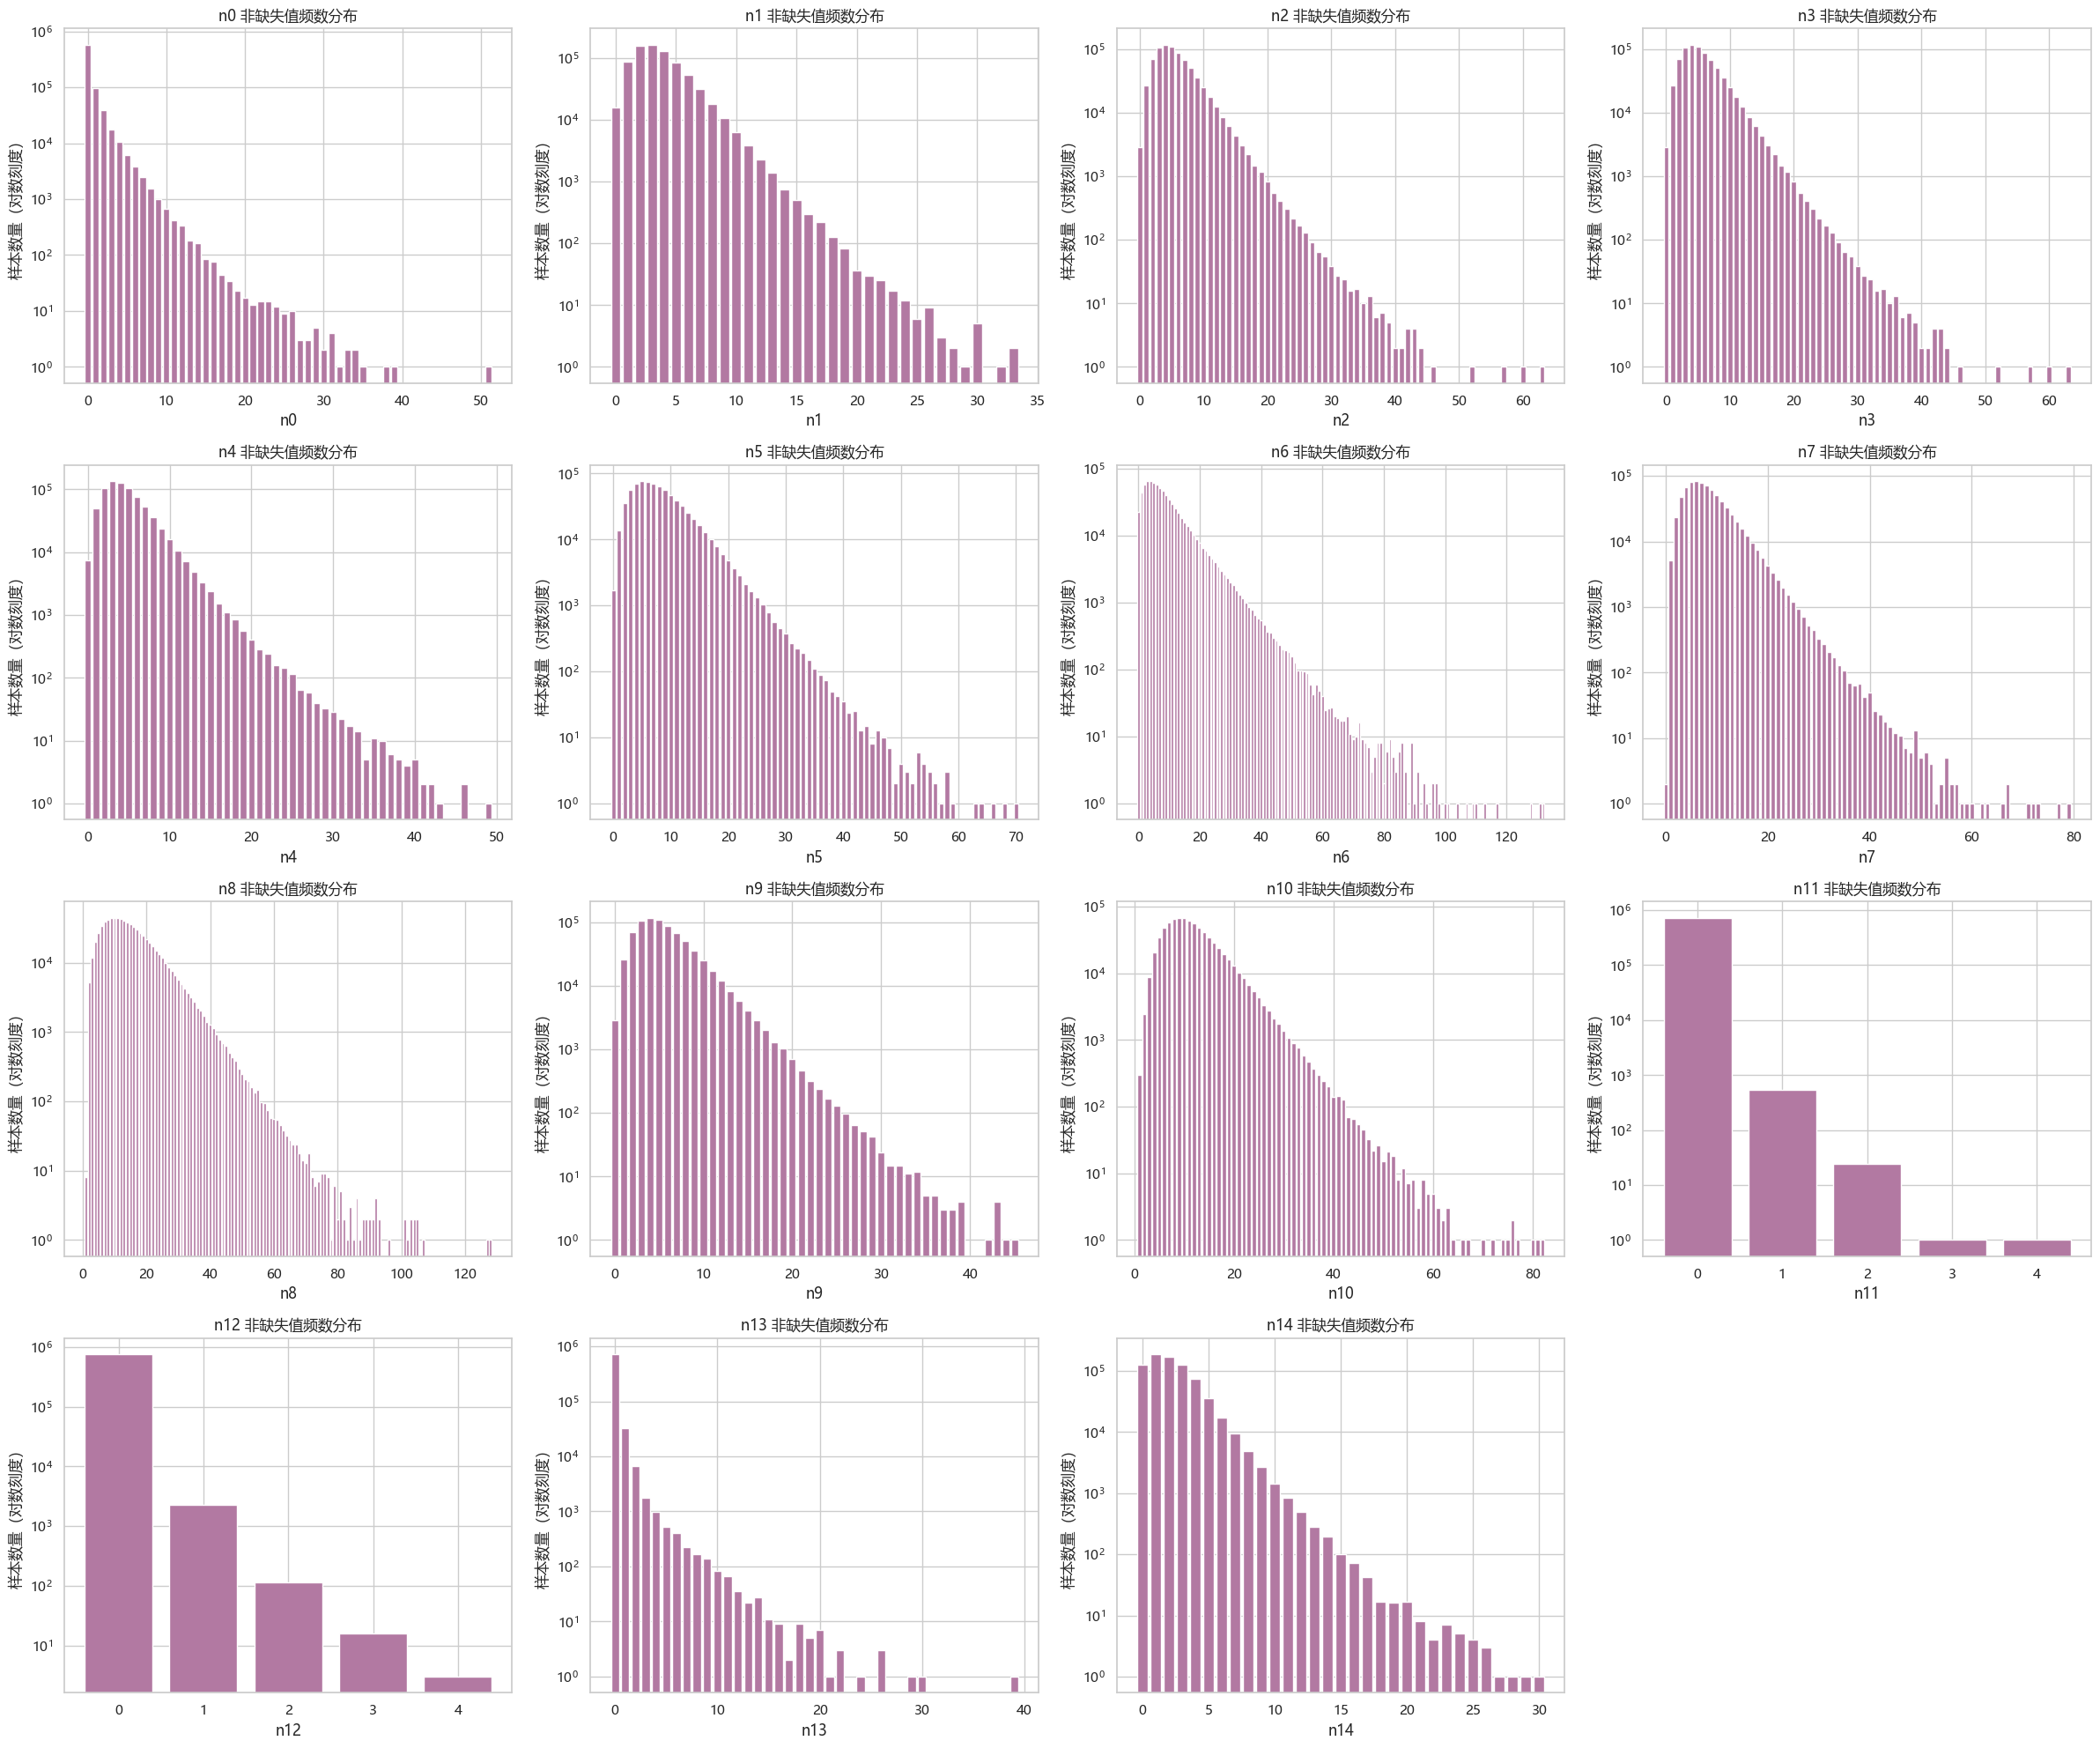

In [23]:
# 匿名字段保留缺失值，汇总时分别观察缺失比例和非缺失值分布。
anonymous_cols = [f"n{i}" for i in range(15)]

anonymous_summary = pd.DataFrame({
    "字段": anonymous_cols,
    "缺失数量": [df_clean[column].isna().sum() for column in anonymous_cols],
    "缺失比例": [df_clean[column].isna().mean() for column in anonymous_cols],
    "非缺失唯一值数": [df_clean[column].nunique(dropna=True) for column in anonymous_cols],
    "最小值": [df_clean[column].min() for column in anonymous_cols],
    "最大值": [df_clean[column].max() for column in anonymous_cols],
    "零值比例（非缺失）": [
        df_clean[column].eq(0).sum() / df_clean[column].notna().sum()
        for column in anonymous_cols
    ],
})

display(
    anonymous_summary.style
    .format({"缺失比例": "{:.2%}", "零值比例（非缺失）": "{:.2%}"})
    .hide(axis="index")
)

# 对数纵轴用于显示被高频零值遮盖的低频计数。
fig, axes = plt.subplots(4, 4, figsize=(24, 20))
for column, ax in zip(anonymous_cols, axes.flat):
    frequency = df_clean[column].dropna().value_counts().sort_index()
    ax.bar(frequency.index, frequency.values, color="#B279A2")
    ax.set_yscale("log")
    ax.set_title(f"{column} 非缺失值频数分布")
    ax.set_xlabel(column)
    ax.set_ylabel("样本数量（对数刻度）")
    ax.locator_params(axis="x", integer=True, nbins=8)

for ax in axes.flat[len(anonymous_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

`n0`–`n14` 为匿名计数特征。统计表单独展示缺失情况和零值集中程度；分布图仅使用非缺失值，并采用对数纵轴显示低频高值。缺失值仍保留为 `NaN`，本步骤不进行填补或数据修改。

### 4.5 特征与目标变量的关系

#### 4.5.1 主要数值字段 × 目标变量

,与 isDefault 的Spearman相关系数
interestRate,0.2546
ficoRangeLow,-0.1306
ficoRangeHigh,-0.1306
dti,0.1060
loanAmnt,0.0705
annualIncome,-0.0673
installment,0.0596
revolUtil,0.0590
pubRec,0.0330
pubRecBankruptcies,0.0267


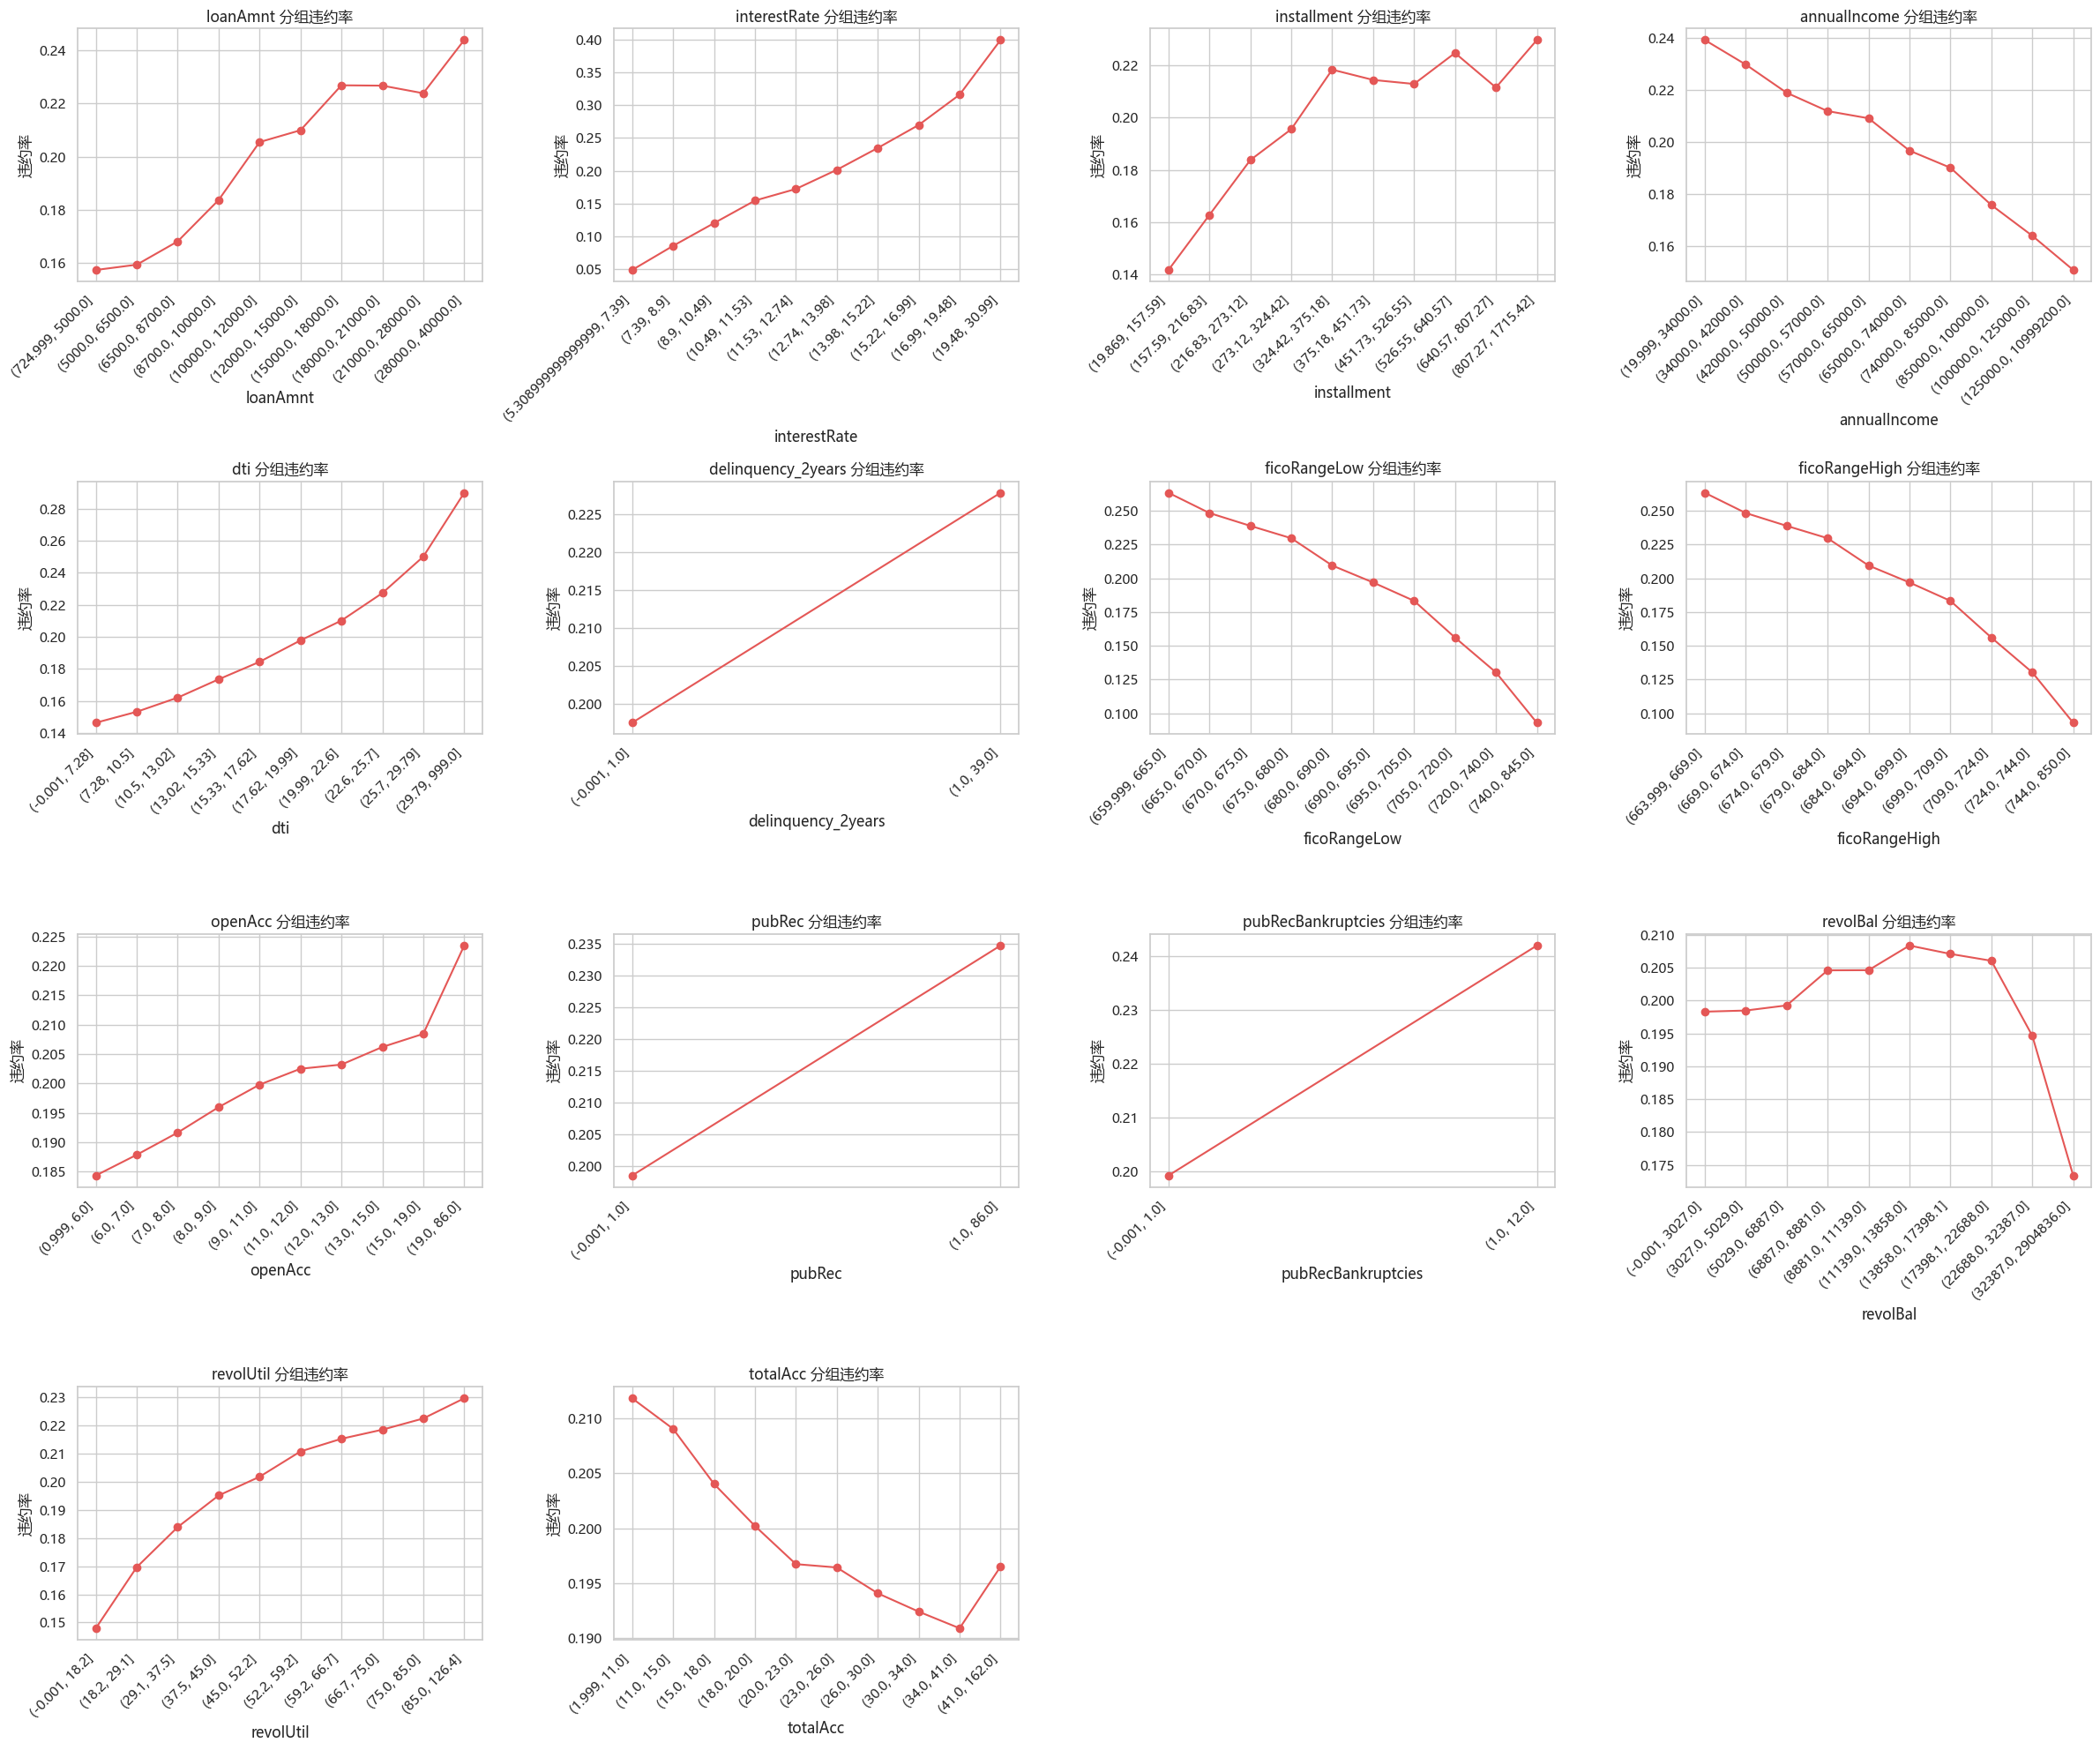

In [24]:
def calculate_grouped_default_rate(data, column, max_groups=10):
    """按原始取值或分位数组计算违约率，仅用于EDA展示。"""
    analysis_data = data[[column, TARGET]].dropna().copy()

    if analysis_data[column].nunique() > max_groups:
        analysis_data["分组"] = pd.qcut(
            analysis_data[column], q=max_groups, duplicates="drop"
        )
    else:
        analysis_data["分组"] = analysis_data[column]

    return (
        analysis_data.groupby("分组", observed=True)[TARGET]
        .agg([("样本数量", "size"), ("违约率", "mean")])
        .reset_index()
    )


# Spearman相关系数用于概括数值字段与违约状态之间的单调关系。
numeric_target_correlations = (
    df_clean[eda_numeric_cols + [TARGET]]
    .corr(method="spearman")[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

display(numeric_target_correlations.to_frame("与 isDefault 的Spearman相关系数"))

# 分组违约率用于补充观察相关系数无法反映的非线性关系。
fig, axes = plt.subplots(4, 4, figsize=(24, 20))
for column, ax in zip(eda_numeric_cols, axes.flat):
    grouped_rate = calculate_grouped_default_rate(df_clean, column)
    positions = range(len(grouped_rate))
    ax.plot(
        positions,
        grouped_rate["违约率"],
        marker="o",
        color="#E45756",
    )
    ax.set_title(f"{column} 分组违约率")
    ax.set_xlabel(column)
    ax.set_ylabel("违约率")
    ax.set_xticks(list(positions))
    ax.set_xticklabels(grouped_rate["分组"].astype(str), rotation=45, ha="right")

for ax in axes.flat[len(eda_numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Spearman相关系数用于概括数值字段与目标变量之间的单调关系。分组违约率图将唯一值较多的字段按分位数分组，唯一值较少的字段保留原始取值。相关性较低不代表字段没有预测价值，分组图可进一步观察非线性变化。

#### 4.5.2 类别字段 × 目标变量

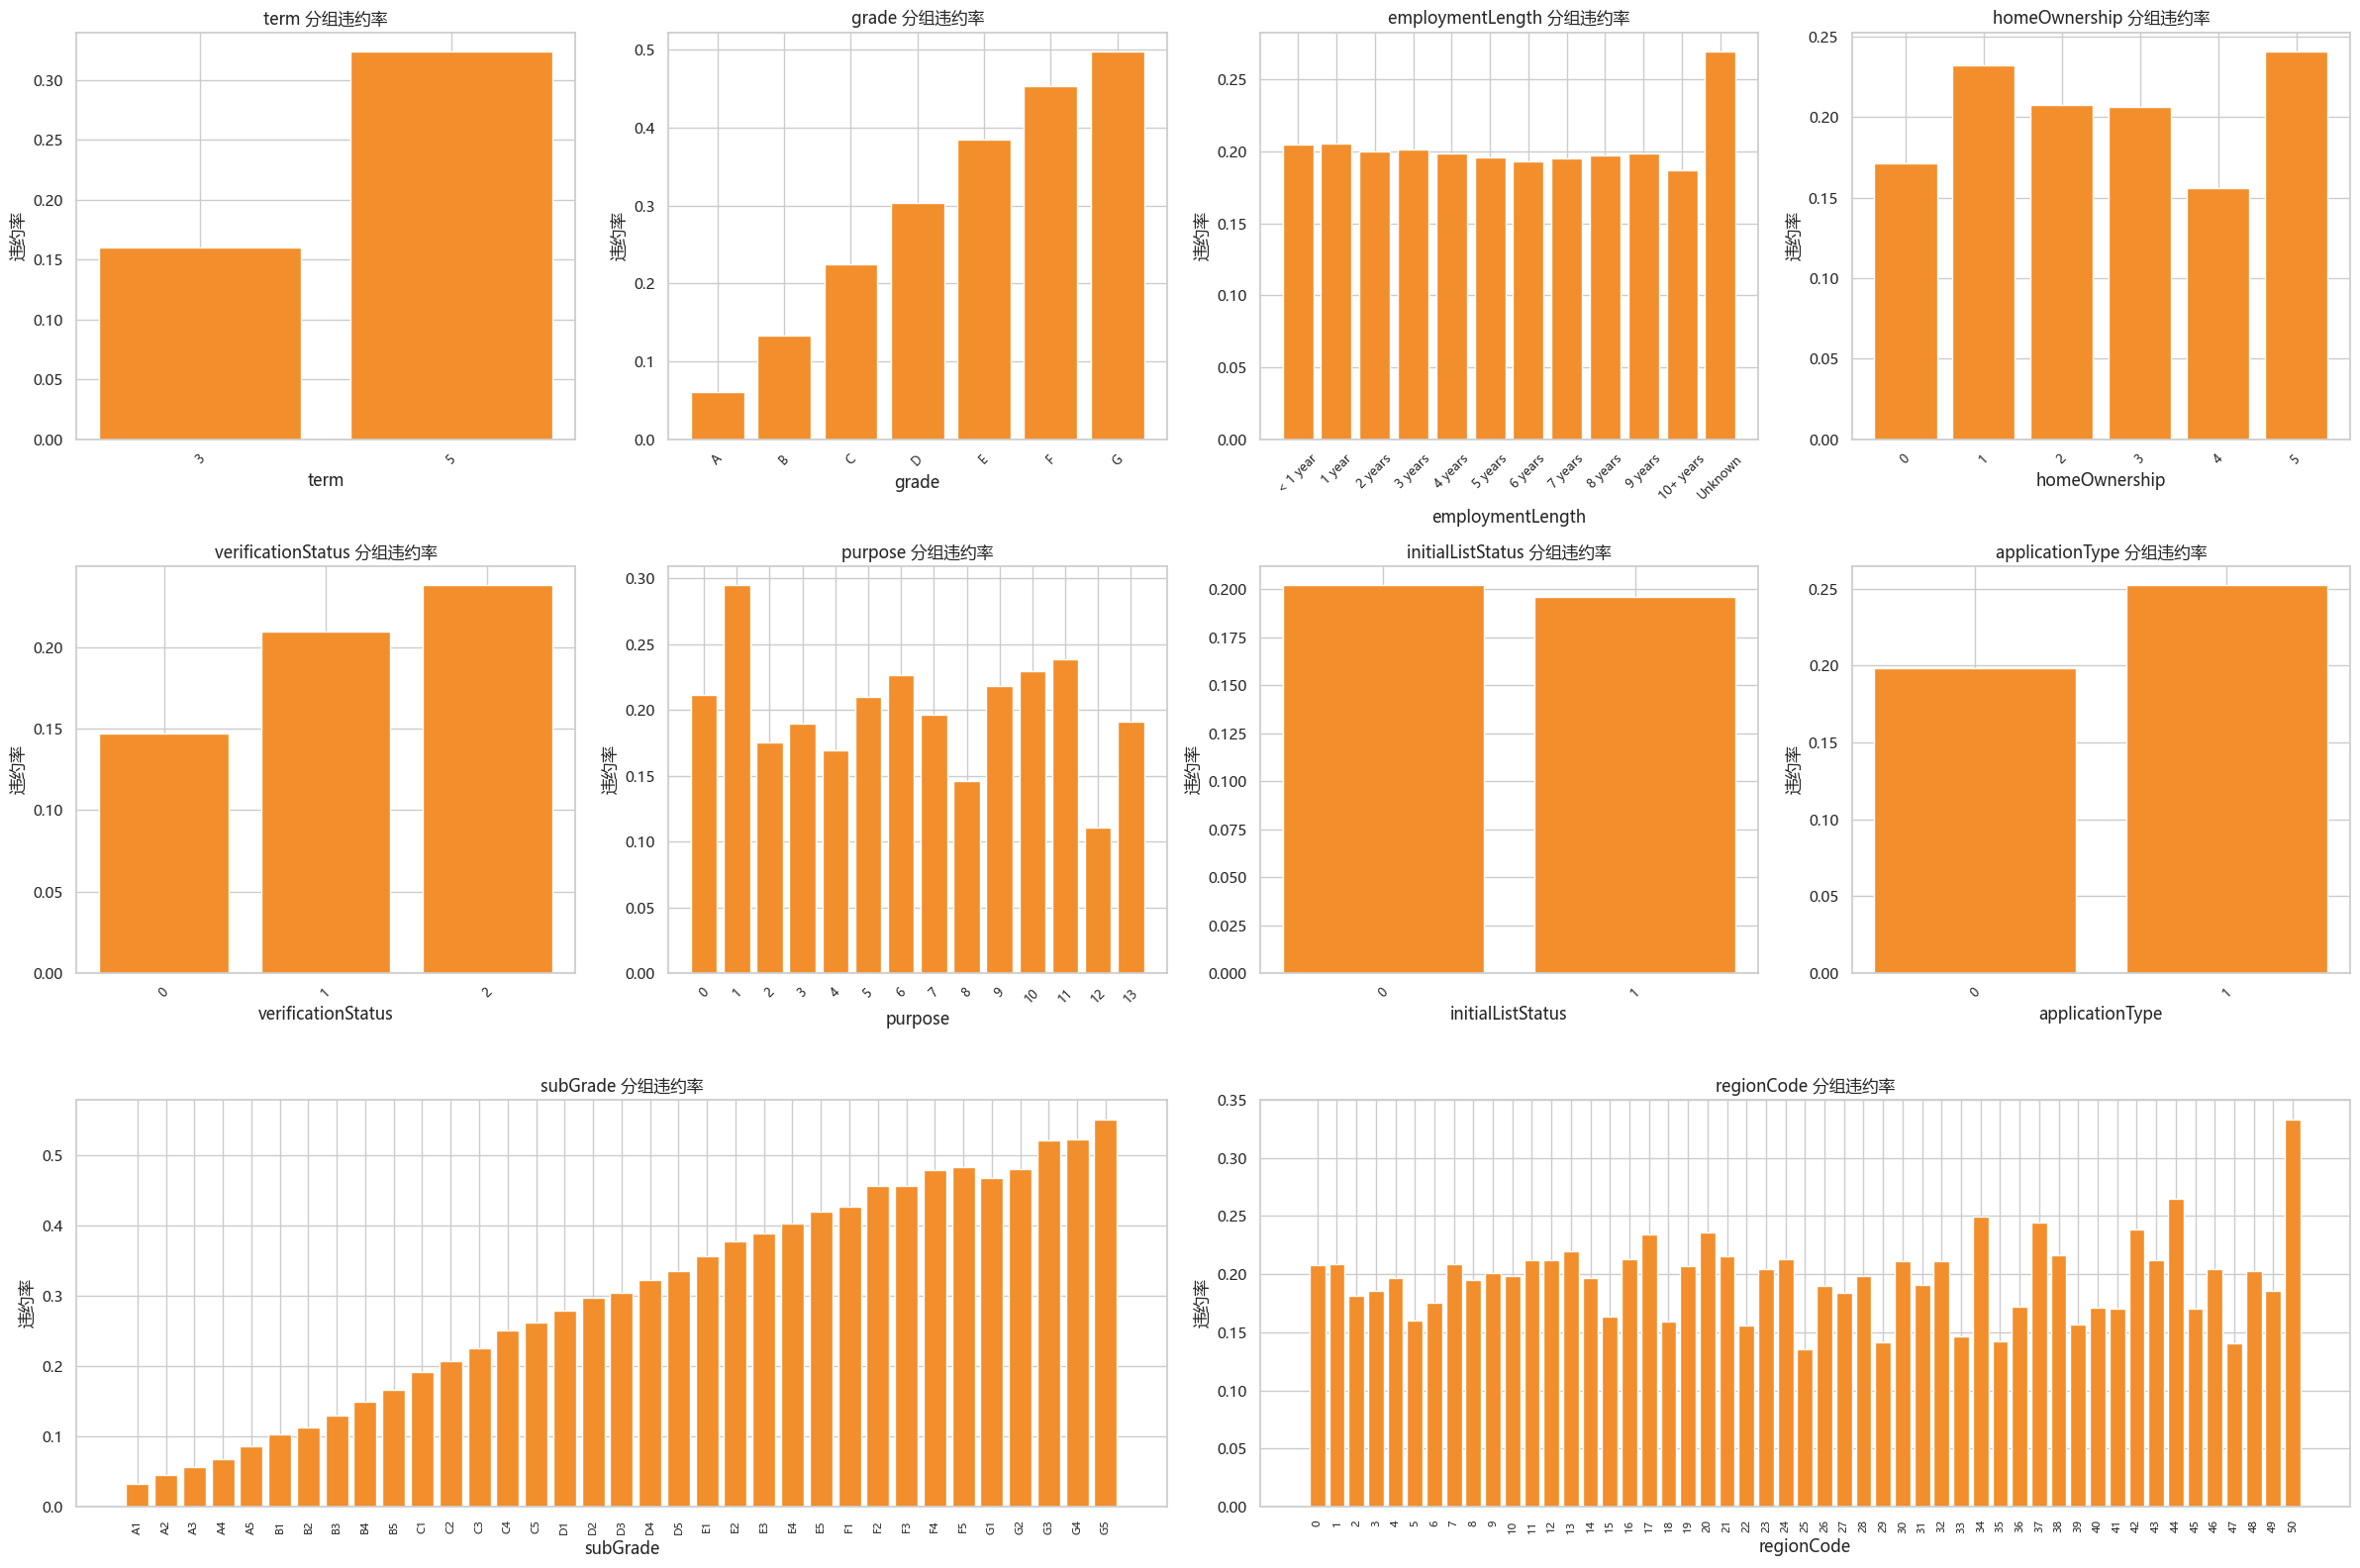

In [25]:
# 按类别计算目标均值；二分类目标的均值即该类别违约率。
regular_target_categorical_cols = [
    column
    for column in eda_categorical_distribution_cols
    if column not in {"subGrade", "regionCode"}
]

fig = plt.figure(figsize=(24, 16))
grid = fig.add_gridspec(3, 4)
axes_by_column = {
    column: fig.add_subplot(grid[index // 4, index % 4])
    for index, column in enumerate(regular_target_categorical_cols)
}
axes_by_column["subGrade"] = fig.add_subplot(grid[2, :2])
axes_by_column["regionCode"] = fig.add_subplot(grid[2, 2:])

for column in eda_categorical_distribution_cols:
    ax = axes_by_column[column]
    default_rate = (
        df_clean.groupby(column, dropna=False)[TARGET]
        .agg([("样本数量", "size"), ("违约率", "mean")])
    )

    if column == "employmentLength":
        category_order = [
            value for value in employment_length_order if value in default_rate.index
        ]
        default_rate = default_rate.reindex(category_order)
    else:
        default_rate = default_rate.sort_index()

    ax.bar(
        default_rate.index.astype(str),
        default_rate["违约率"],
        color="#F28E2B",
    )
    ax.set_title(f"{column} 分组违约率")
    ax.set_xlabel(column)
    ax.set_ylabel("违约率")
    ax.tick_params(
        axis="x",
        rotation=90 if column in {"subGrade", "regionCode"} else 45,
        labelsize=8 if column in {"subGrade", "regionCode"} else 9,
    )

plt.tight_layout()
plt.show()

类别字段按原始类别顺序展示各组违约率。数值编码类别只能视为类别标签，不能根据编码大小推断业务含义；分组违约率反映关联而非因果关系。

#### 4.5.3 匿名字段 × 目标变量

,与 isDefault 的Spearman相关系数
n14,0.0858
n3,0.0686
n2,0.0686
n9,0.0668
n1,0.0381
n7,0.0319
n10,0.0249
n5,-0.0208
n0,0.0204
n13,0.0148


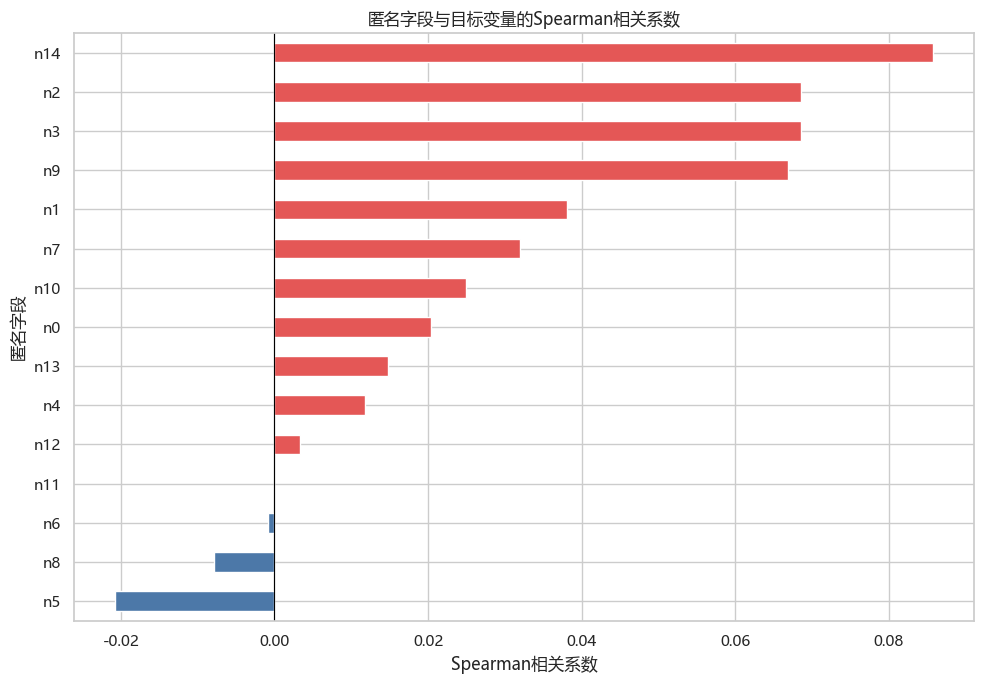

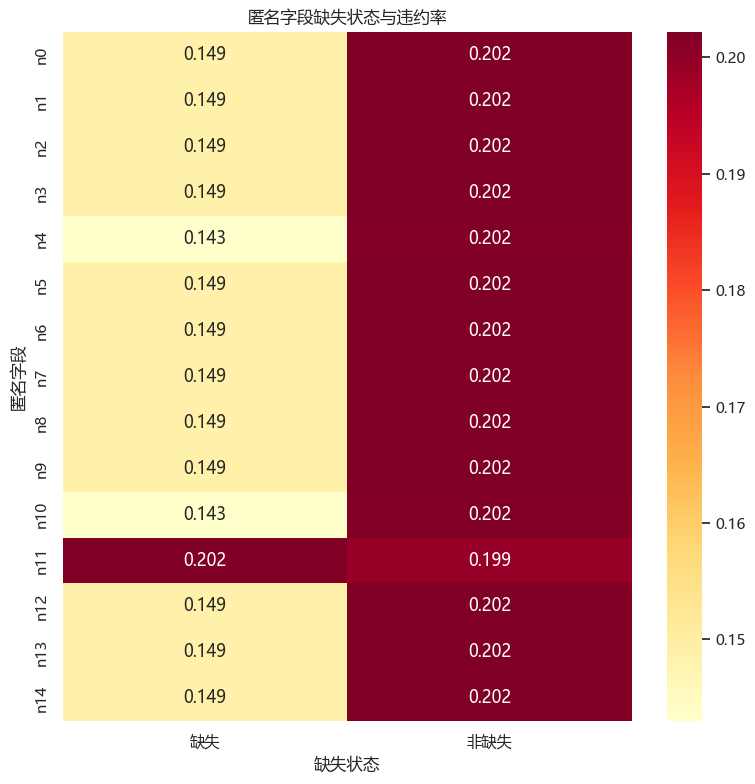

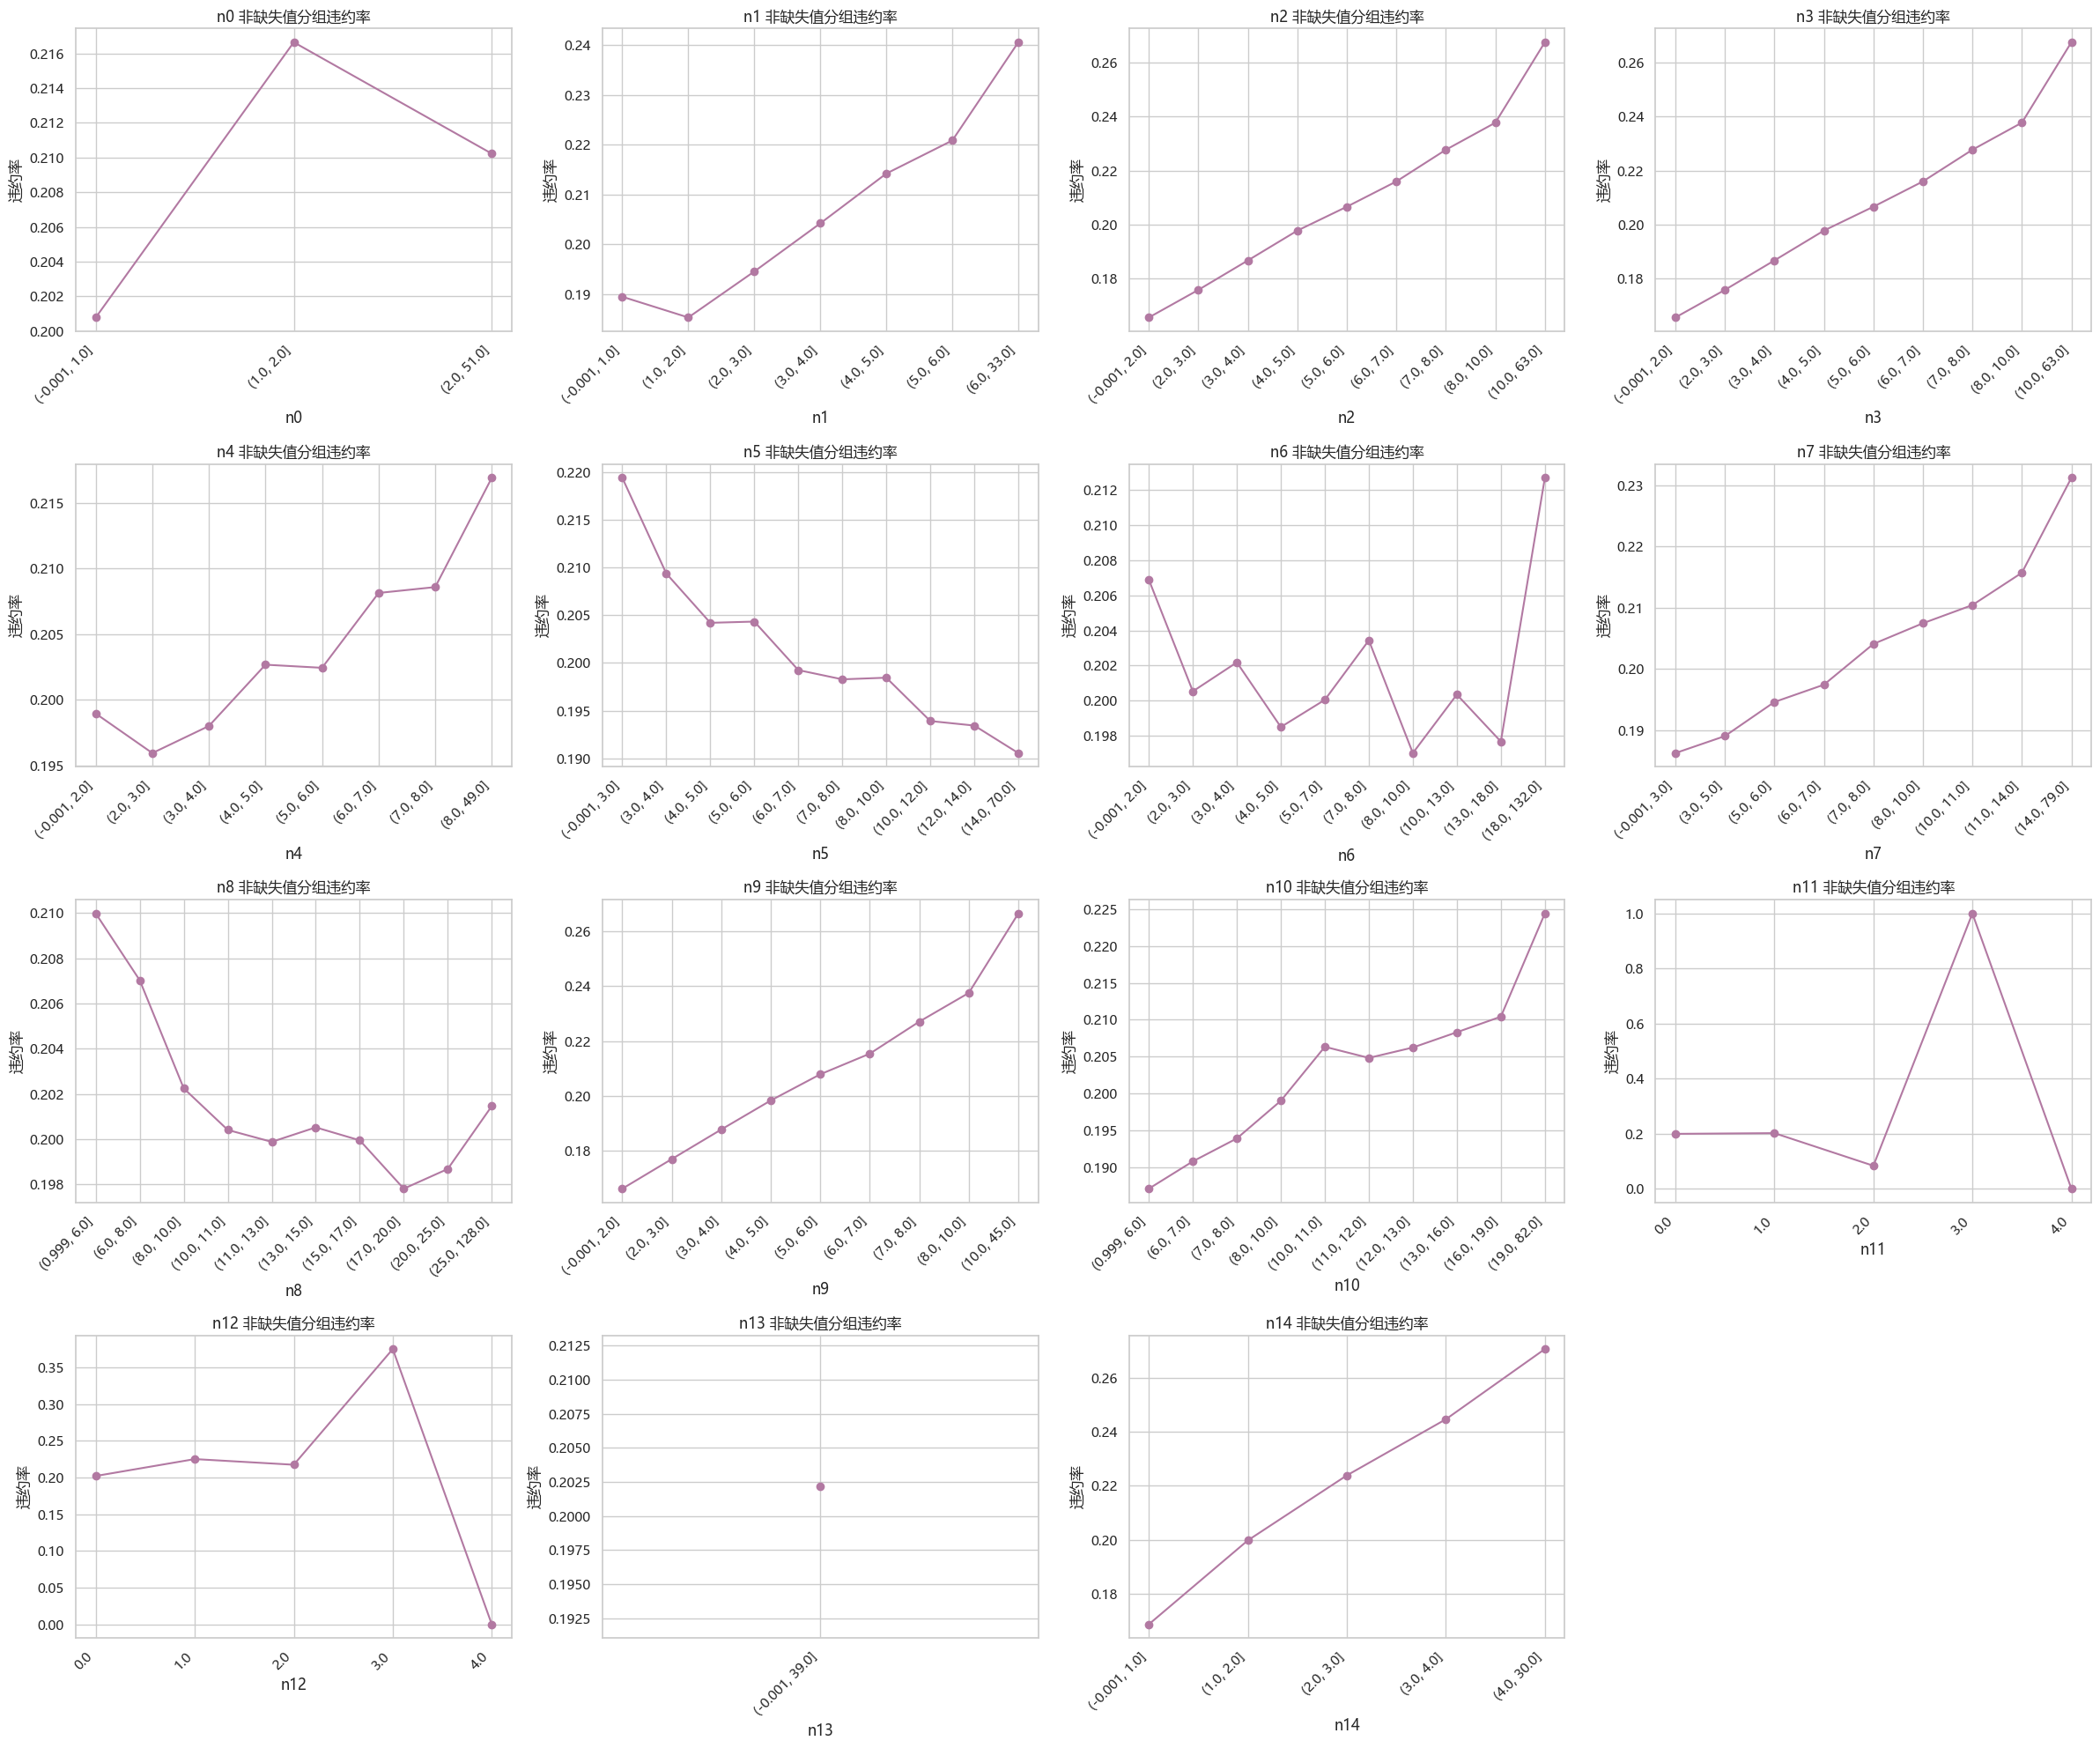

In [26]:
# 相关系数按字段自动使用与目标变量同时非缺失的记录。
anonymous_target_correlations = (
    df_clean[anonymous_cols + [TARGET]]
    .corr(method="spearman")[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

display(
    anonymous_target_correlations
    .to_frame("与 isDefault 的Spearman相关系数")
    .style.format("{:.4f}")
)

correlations_for_plot = anonymous_target_correlations.sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
colors = [
    "#4C78A8" if value < 0 else "#E45756"
    for value in correlations_for_plot
]
correlations_for_plot.plot(kind="barh", color=colors, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("匿名字段与目标变量的Spearman相关系数")
ax.set_xlabel("Spearman相关系数")
ax.set_ylabel("匿名字段")
plt.tight_layout()
plt.show()

# 缺失状态可能携带独立风险信息，因此与非缺失记录分开比较。
anonymous_missing_default_rate = []
for column in anonymous_cols:
    missing_status = np.where(df_clean[column].isna(), "缺失", "非缺失")
    status_rate = (
        df_clean.assign(缺失状态=missing_status)
        .groupby("缺失状态")[TARGET]
        .mean()
    )
    anonymous_missing_default_rate.append({
        "字段": column,
        "缺失": status_rate.get("缺失", np.nan),
        "非缺失": status_rate.get("非缺失", np.nan),
    })

anonymous_missing_default_rate = pd.DataFrame(
    anonymous_missing_default_rate
).set_index("字段")

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    anonymous_missing_default_rate,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    ax=ax,
)
ax.set_title("匿名字段缺失状态与违约率")
ax.set_xlabel("缺失状态")
ax.set_ylabel("匿名字段")
plt.tight_layout()
plt.show()

# 对匿名字段的非缺失值进一步观察分组违约率。
fig, axes = plt.subplots(4, 4, figsize=(24, 20))
for column, ax in zip(anonymous_cols, axes.flat):
    grouped_rate = calculate_grouped_default_rate(df_clean, column)
    positions = range(len(grouped_rate))
    ax.plot(
        positions,
        grouped_rate["违约率"],
        marker="o",
        color="#B279A2",
    )
    ax.set_title(f"{column} 非缺失值分组违约率")
    ax.set_xlabel(column)
    ax.set_ylabel("违约率")
    ax.set_xticks(list(positions))
    ax.set_xticklabels(grouped_rate["分组"].astype(str), rotation=45, ha="right")

for ax in axes.flat[len(anonymous_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

匿名字段先使用Spearman相关系数概括非缺失取值与目标变量的单调关系，再比较缺失与非缺失样本的违约率，并观察非缺失值的分组违约率。由于字段业务含义未知，本节只描述统计关联，不解释变化原因，也不据此填补缺失值。

### 4.6 放款时间与违约率变化

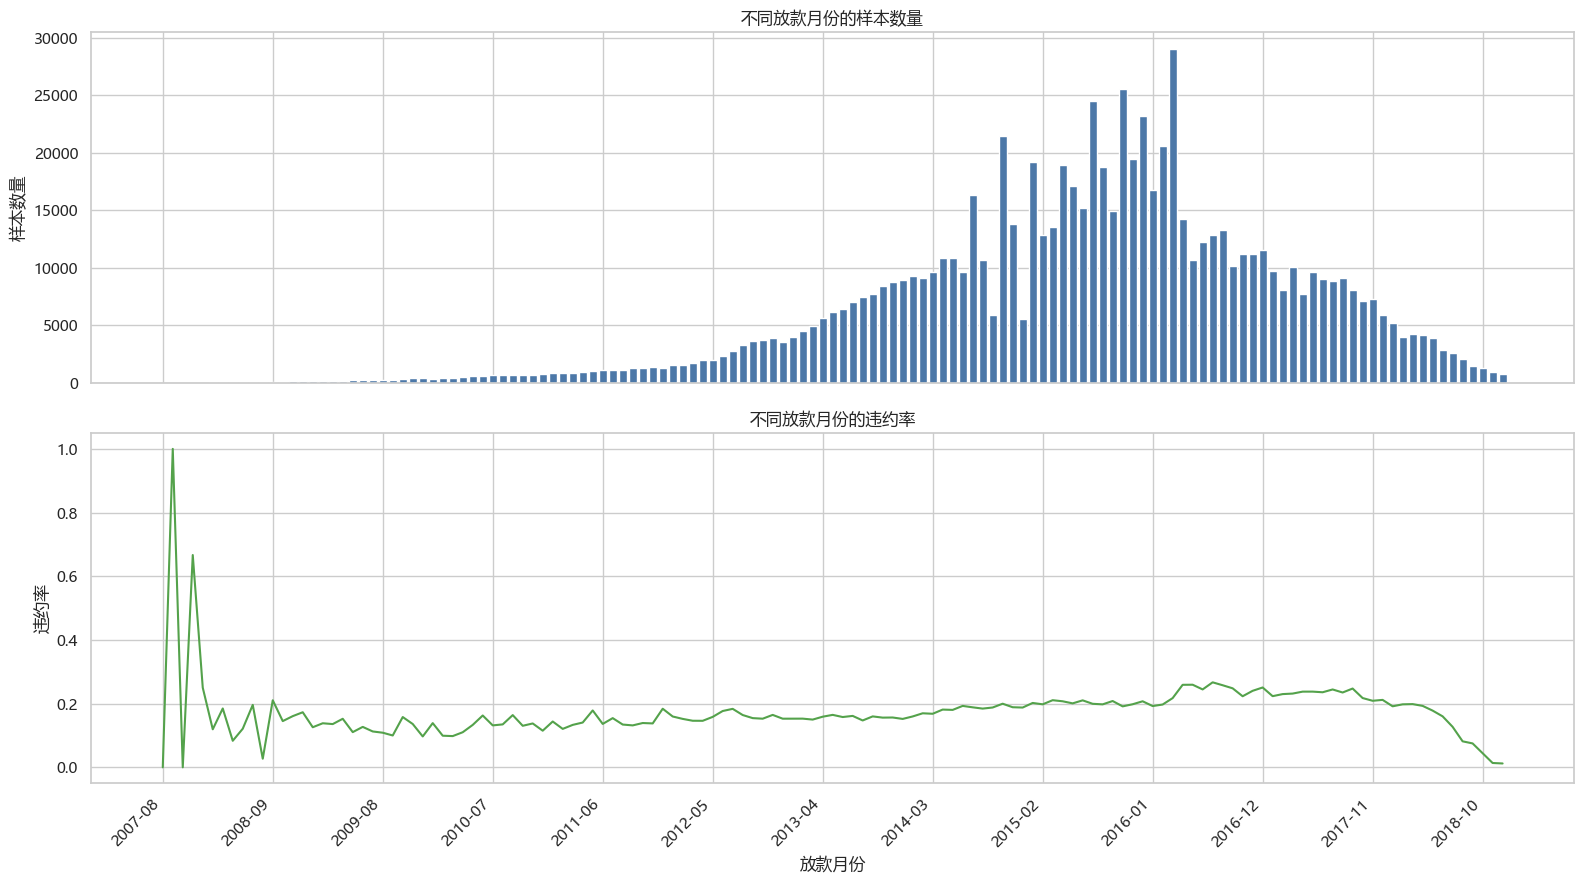

统计项,结果
月份数量,135
最少月样本数,1
最多月样本数,29038


In [27]:
# 临时解析日期用于EDA，不覆盖清洗数据中的原始字符串。
issue_date_for_eda = pd.to_datetime(
    df_clean["issueDate"], format="%Y-%m-%d", errors="coerce"
)
monthly_default = (
    df_clean.assign(issueMonth=issue_date_for_eda.dt.to_period("M").astype(str))
    .groupby("issueMonth")[TARGET]
    .agg([("样本数量", "size"), ("违约率", "mean")])
    .reset_index()
)

# 使用相同横轴分别展示每月样本量和违约率，避免忽略小样本月份。
positions = np.arange(len(monthly_default))
fig, (count_ax, rate_ax) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

count_ax.bar(positions, monthly_default["样本数量"], color="#4C78A8")
count_ax.set_title("不同放款月份的样本数量")
count_ax.set_ylabel("样本数量")

rate_ax.plot(
    positions,
    monthly_default["违约率"],
    color="#54A24B",
    linewidth=1.5,
)
rate_ax.set_title("不同放款月份的违约率")
rate_ax.set_xlabel("放款月份")
rate_ax.set_ylabel("违约率")

tick_step = max(1, len(monthly_default) // 12)
tick_positions = positions[::tick_step]
rate_ax.set_xticks(tick_positions)
rate_ax.set_xticklabels(
    monthly_default["issueMonth"].iloc[::tick_step],
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

monthly_time_summary = pd.DataFrame({
    "统计项": ["月份数量", "最少月样本数", "最多月样本数"],
    "结果": [
        len(monthly_default),
        monthly_default["样本数量"].min(),
        monthly_default["样本数量"].max(),
    ],
})
display(monthly_time_summary.style.hide(axis="index"))

放款月份趋势同时展示样本数量和违约率。数据早期部分月份样本很少，单月违约率可能出现0或1等剧烈波动，因此不能将这些波动直接解释为稳定的时间趋势；后续按时间划分数据时还需考虑观察窗口和样本量。

## 5. 本阶段结果

- 原始数据通过 `df.copy()` 得到独立清洗副本，原始CSV未被覆盖。
- 原数据未发现重复记录；删除1,177条指定字段缺失记录，将 `employmentLength` 缺失值保留为 `Unknown`，并保留 `n0`～`n14` 的原始缺失值。
- 删除2条负数 `dti` 记录，并按IQR边界删除47条 `revolUtil` 极端值；其他具有潜在风险识别意义的统计极端值予以保留。
- 字符串、等级、工作年限和日期字段通过一致性检查，未修改原始日期字符串。
- 清洗后数据包含798,774条样本和47个字段，共删除1,226条记录，结果保存为 `credit_data_cleaned.csv`。
- EDA覆盖目标变量、主要数值字段、类别字段和匿名字段的单变量分布，并分别分析其与目标变量的关系。
- 匿名字段与目标变量的Spearman相关系数绝对值均低于0.1，未发现明显的单变量单调相关性；其非线性关系、缺失信息和组合预测价值仍需通过后续模型验证。
- 放款月份分析显示早期部分月份样本量很少，时间违约率波动需要结合月度样本量谨慎解释。